In [ ]:
# 📊 Stock Categorization Project

"""
Objective
Categorize securities from `security.txt` into three groups:
- 5x Group - High liquidity stocks with good trading volume
- 3x Group - Medium liquidity stocks
- Only Delivery Group - All other stocks
"""

In [62]:
# PHASE 1: SETUP & PREPARATION


import pandas as pd  # For data manipulation and analysis
import numpy as np   # For numerical operations
import os           # For file path operations
import warnings     # To suppress warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')


pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)        # Don't wrap DataFrame display
pd.set_option('display.max_colwidth', 50)   # Max width for column content

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 1.26.4


In [63]:
# Defining File Paths
# Base directory 
base_dir = os.getcwd()
print(f"Working Directory: {base_dir}\n")

file_paths = {
    'security': 'security.txt',
    'bhav_copy_1': 'BhavCopy_NSE_CM (1).csv',
    'bhav_copy_2': 'BhavCopy_NSE_CM (2).csv',
    'bhav_copy_3': 'BhavCopy_NSE_CM (3).csv',
    'fo_securities': 'APPSEC_COLLVAL_21112025.csv',  
    'var_file': 'C_VAR1_06112025_6.DAT',
    'output': 'securities_categorized.csv'
}

print("Verifying file existence:\n")
all_files_exist = True

for file_key, file_path in file_paths.items():
    if file_key != 'output':  
        full_path = os.path.join(base_dir, file_path)
        exists = os.path.exists(full_path)
        status = "Yes" if exists else "No"
        print(f"{status} {file_key}: {file_path}")
        if not exists:
            all_files_exist = False

if all_files_exist:
    print("\n All required files are present!")
else:
    print("\n Some files are missing. Please check the file paths.")

Working Directory: c:\Users\Aditya\OneDrive\Desktop\Data Analyst Assignment Files

Verifying file existence:

Yes security: security.txt
Yes bhav_copy_1: BhavCopy_NSE_CM (1).csv
Yes bhav_copy_2: BhavCopy_NSE_CM (2).csv
Yes bhav_copy_3: BhavCopy_NSE_CM (3).csv
Yes fo_securities: APPSEC_COLLVAL_21112025.csv
Yes var_file: C_VAR1_06112025_6.DAT

 All required files are present!


In [64]:

# Define Column Headers for security.txt

# These headers are from the nse security headers file

security_headers = [
    "instrument_token", "symbol", "series", "instrumenttype", "issuedcapital", 
    "permittedtotrade", "creditrating", "normalmarketstatus", "normalmarketeligibility", 
    "oddlotmarketstatus", "oddlotmarketeligibility", "spotmarketstatus", 
    "spotmarketeligibility", "auctionmarketstatus", "auctionmarketeligibility",
    "callauction1marketstatus", "callauction1marketeligibility", 
    "callauction2marketstatus", "callauction2marketeligibility",
    "boardlotquantity", "ticsize", "name", "survind", "issuestartdate", 
    "interestpaymentdate", "maturitydate", "freezepercent",
    "listingdate", "expulsiondate", "readmissiondate", "expirydate", 
    "recorddate", "nodeliverystartdate", "nodeliveryenddate",
    "participantinmarketindex", "aon", "minimumfill", "settlementtype", 
    "bookclosurestartdate", "bookclosureenddate", "dividend",
    "rights", "bonus", "interest", "agm", "egm", "marketmakerspread", 
    "marketmakerminquantity", "ssec", "remark", "localupdatedatetime",
    "deleteflag", "facevalue", "isin"
]

print(f"Total columns in security.txt: {len(security_headers)}")
print(f"\n Key columns we'll use:")
print(f"   - symbol (position 1)")
print(f"   - series (position 2)")
print(f"   - creditrating/price_range (position 6)")
print(f"   - isin (position 53)")

Total columns in security.txt: 54

 Key columns we'll use:
   - symbol (position 1)
   - series (position 2)
   - creditrating/price_range (position 6)
   - isin (position 53)


In [65]:
# Helper Functions

def calculate_price_band(price_range):
    """
    Calculate price band percentage from price range string.
    
    Args:
        price_range (str): Price range in format "180.00-220.00"
    
    Returns:
        float: Price band percentage
    """
    try:
        if pd.isna(price_range) or price_range == '':
            return 0.0
        
        # Split the range by '-'
        parts = str(price_range).split('-')
        
        if len(parts) != 2:
            return 0.0
        
        low = float(parts[0].strip())
        high = float(parts[1].strip())
        
        # Calculate mid price
        mid = (low + high) / 2
        
        # Calculate price band percentage
        if mid == 0:
            return 0.0
        
        price_band_pct = ((high - mid) / mid) * 100
        
        return round(price_band_pct, 2)
    
    except Exception as e:
        return 0.0


def categorize_security(row):
    """
    Categorize a security based on the given rules.
    
    Args:
        row (pd.Series): Row containing security data
    
    Returns:
        str: Category (5x, 3x, or Only Delivery)
    """
    series = row.get('series', '')
    avg_traded_value = row.get('avg_traded_value', 0)
    price_band = row.get('price_band_pct', 0)
    is_fo = row.get('is_fo_stock', False)
    variance = row.get('variance', 100)
    
    # Convert traded value to lakhs for comparison
    avg_traded_value_lakhs = avg_traded_value / 100000
    
    # Check for 5x category
    # Rule 1: F&O stock with variance <= 20%
    if is_fo and variance <= 20:
        return '5x'
    
    # Rule 2: Series in [EQ, BE, BZ] AND avg value > 50 lakh AND price band > 5%
    if series in ['EQ', 'BE', 'BZ']:
        if avg_traded_value_lakhs > 50 and price_band > 5:
            return '5x'
    
    # Check for 3x category
    # Rule 1: F&O stock with variance <= 33.33%
    if is_fo and variance <= 33.33:
        return '3x'
    
    # Rule 2: Series in [EQ, BE, BZ] AND avg value > 20 lakh AND price band > 5%
    if series in ['EQ', 'BE', 'BZ']:
        if avg_traded_value_lakhs > 20 and price_band > 5:
            return '3x'
    
    # Default: Only Delivery
    return 'Only Delivery'


print("Helper functions defined:")
print("   - calculate_price_band(): Calculates price band % from range")
print("   - categorize_security(): Applies categorization rules")

Helper functions defined:
   - calculate_price_band(): Calculates price band % from range
   - categorize_security(): Applies categorization rules


In [66]:

# Loading security.txt - Master Securities File


print("Loading security.txt...\n")

try:
    
    df_security = pd.read_csv(
        file_paths['security'],
        sep='|',
        header=None,
        names=security_headers,
        skiprows=1,  # Skip the first metadata line (NEATCM|7.85.00|...)
        dtype=str,   # Read all as string initially
        on_bad_lines='skip'  #
    )
    
    print(f" security.txt loaded successfully!")
    print(f" Total records: {len(df_security):,}")
    print(f" Total columns: {len(df_security.columns)}")
    print(f"\n First 3 records:\n")
    display(df_security[['symbol', 'series', 'creditrating', 'name', 'isin']].head(3))
    
    # Check series distribution
    print(f"\n Series Distribution (Top 10):")
    print(df_security['series'].value_counts().head(10))
    
except Exception as e:
    print(f" Error loading security.txt: {e}")
    df_security = None

Loading security.txt...

 security.txt loaded successfully!
 Total records: 40,656
 Total columns: 54

 First 3 records:



,symbol,series,creditrating,name,isin
0,011NSETEST,EQ,180.00-220.00,011NSETEST,DUMMYSAN005
1,021NSETEST,EQ,180.00-220.00,021NSETEST,DUMMYSAN006
2,031NSETEST,EQ,180.00-220.00,031NSETEST,DUMMYSAN007



 Series Distribution (Top 10):
series
EQ    5589
BL    4765
RL    4650
SG    3900
BE    3375
MF    2910
IQ    2651
AF    2014
SM    1133
TB     905
Name: count, dtype: int64


In [67]:
# Loading BhavCopy Files - 3 Days of Trading Data

print("Loading BhavCopy files...\n")

# List to store individual BhavCopy dataframes
bhav_dfs = []

try:
    
    for i, file_key in enumerate(['bhav_copy_1', 'bhav_copy_2', 'bhav_copy_3'], 1):
        print(f"Loading {file_paths[file_key]}...")
        
        df_temp = pd.read_csv(file_paths[file_key])
        
        # Add a column to identify which day this data is from
        df_temp['Day'] = f'Day_{i}'
        
        bhav_dfs.append(df_temp)
        print(f"   Loaded {len(df_temp):,} records from Day {i}")
    
    
    df_bhav_combined = pd.concat(bhav_dfs, ignore_index=True)
    
    print(f"\n All BhavCopy files loaded successfully!")
    print(f" Total combined records: {len(df_bhav_combined):,}")
    print(f" Columns: {len(df_bhav_combined.columns)}")
    
    print(f"\n Key columns present:")
    key_cols = ['TckrSymb', 'SctySrs', 'ClsPric', 'TtlTrfVal', 'TtlTradgVol']
    for col in key_cols:
        if col in df_bhav_combined.columns:
            print(f"   {col}")
        else:
            print(f"   {col} (MISSING!)")
    
    print(f"\n Sample data from combined BhavCopy:")
    display(df_bhav_combined[['TckrSymb', 'SctySrs', 'ClsPric', 'TtlTrfVal', 'Day']].head(5))
    
    print(f"\n Records per day:")
    print(df_bhav_combined['Day'].value_counts().sort_index())

except Exception as e:
    print(f" Error loading BhavCopy files: {e}")
    df_bhav_combined = None

Loading BhavCopy files...

Loading BhavCopy_NSE_CM (1).csv...
   Loaded 3,189 records from Day 1
Loading BhavCopy_NSE_CM (2).csv...
   Loaded 3,183 records from Day 2
Loading BhavCopy_NSE_CM (3).csv...
   Loaded 3,216 records from Day 3

 All BhavCopy files loaded successfully!
 Total combined records: 9,588
 Columns: 35

 Key columns present:
   TckrSymb
   SctySrs
   ClsPric
   TtlTrfVal
   TtlTradgVol

 Sample data from combined BhavCopy:


,TckrSymb,SctySrs,ClsPric,TtlTrfVal,Day
0,SGBJUN28,GB,12352.31,6033703.49,Day_1
1,SGBN28VIII,GB,12449.49,2015023.16,Day_1
2,SGBMAY29I,GB,12467.72,9887206.59,Day_1
3,SGBJUN29II,GB,12450.09,1304701.89,Day_1
4,SGBJU29III,GB,12554.66,1647698.00,Day_1



 Records per day:
Day
Day_1    3189
Day_2    3183
Day_3    3216
Name: count, dtype: int64


In [68]:

# Load APPSEC File - F&O Securities List


print("Loading APPSEC F&O securities file...\n")

try:
    # Define column names for APPSEC file (no headers in file)
    appsec_columns = ['serial_no', 'symbol', 'isin', 'price', 'variance']
    
    # Read APPSEC file
    df_appsec = pd.read_csv(
        file_paths['fo_securities'],
        header=None,
        names=appsec_columns,
        dtype={'serial_no': int, 'symbol': str, 'isin': str, 'price': float, 'variance': float}
    )
    
    print(f"APPSEC file loaded successfully!")
    print(f"Total F&O securities: {len(df_appsec):,}")
    
    print(f"\nSample F&O securities:")
    display(df_appsec[['symbol', 'price', 'variance']].head(10))
    
    print(f"\nVariance statistics:")
    print(f"  • Min variance: {df_appsec['variance'].min():.2f}%")
    print(f"  • Max variance: {df_appsec['variance'].max():.2f}%")
    print(f"  • Mean variance: {df_appsec['variance'].mean():.2f}%")
    print(f"  • Median variance: {df_appsec['variance'].median():.2f}%")
    
    # Count how many qualify for 5x and 3x based on variance alone
    count_5x_variance = len(df_appsec[df_appsec['variance'] <= 20])
    count_3x_variance = len(df_appsec[df_appsec['variance'] <= 33.33])
    
    print(f"\n F&O stocks by variance criteria:")
    print(f"  • Variance ≤ 20% (qualify for 5x): {count_5x_variance}")
    print(f"  • Variance ≤ 33.33% (qualify for 3x): {count_3x_variance}")

except Exception as e:
    print(f" Error loading APPSEC file: {e}")
    df_appsec = None

Loading APPSEC F&O securities file...

APPSEC file loaded successfully!
Total F&O securities: 1,033

Sample F&O securities:


,symbol,price,variance
0,ABLBL,132.23,20.00
1,AARTIPHARM,712.85,20.00
2,ARSSBL,745.10,20.00
3,DEEPAKNTR,1704.30,20.00
4,THANGAMAYL,3161.20,21.16
5,INDIAGLYCO,1155.80,20.00
6,TVSSCS,113.36,20.00
7,GVT&D,3069.20,20.00
8,NFL,89.30,20.00
9,VIKRAN,110.21,20.00



Variance statistics:
  • Min variance: 5.00%
  • Max variance: 100.00%
  • Mean variance: 18.82%
  • Median variance: 20.00%

 F&O stocks by variance criteria:
  • Variance ≤ 20% (qualify for 5x): 952
  • Variance ≤ 33.33% (qualify for 3x): 1029


In [69]:
# Load C_VAR1 File - Variance/Risk Data

print("Loading C_VAR1 variance file...\n")

try:
    # Read the entire file
    with open(file_paths['var_file'], 'r') as f:
        lines = f.readlines()
    
    print(f"Total lines in file: {len(lines)}")
    
    # Filter only lines starting with "20," (stock data lines)
    stock_lines = [line.strip() for line in lines if line.startswith('20,')]
    
    print(f"Stock data lines (starting with '20,'): {len(stock_lines)}")
    
    # Parse the stock lines
    var_data = []
    for line in stock_lines:
        parts = line.split(',')
        if len(parts) >= 10:  # Ensure we have all columns
            var_data.append({
                'symbol': parts[1].strip(),
                'series': parts[2].strip(),
                'isin': parts[3].strip(),
                'variance': float(parts[9].strip())  # Last column
            })
    
    # Create DataFrame
    df_var = pd.DataFrame(var_data)
    
    print(f"\nC_VAR1 file processed successfully!")
    print(f"Total securities with variance data: {len(df_var):,}")
    
    print(f"\nSample variance data:")
    display(df_var.head(10))
    
    print(f"\nVariance statistics from VAR file:")
    print(f"  • Min variance: {df_var['variance'].min():.2f}%")
    print(f"  • Max variance: {df_var['variance'].max():.2f}%")
    print(f"  • Mean variance: {df_var['variance'].mean():.2f}%")
    print(f"  • Median variance: {df_var['variance'].median():.2f}%")
    
    # Count by variance thresholds
    count_var_5x = len(df_var[df_var['variance'] <= 20])
    count_var_3x = len(df_var[df_var['variance'] <= 33.33])
    
    print(f"\nSecurities by variance criteria (from VAR file):")
    print(f"  • Variance ≤ 20%: {count_var_5x}")
    print(f"  • Variance ≤ 33.33%: {count_var_3x}")

except Exception as e:
    print(f"Error loading C_VAR1 file: {e}")
    df_var = None

Loading C_VAR1 variance file...

Total lines in file: 17461
Stock data lines (starting with '20,'): 17460

C_VAR1 file processed successfully!
Total securities with variance data: 17,460

Sample variance data:


,symbol,series,isin,variance
0,0MOFSL26,N1,INE338I07156,10.0
1,0MOFSL27,N3,INE338I07099,10.0
2,0NHIT34,N0,INE0H7R07066,10.0
3,0NHIT35,N0,INE0H7R07058,10.0
4,0RL34,N0,INE020B08FJ3,10.0
5,0SCL26,YR,INE148I07SF0,10.0
6,0SCL27,YW,INE148I07SK0,10.0
7,1003IIFL29,NC,INE413U07301,10.0
8,1003ISFL28,N4,INE413U07269,10.0
9,1003SCFL31,Z4,INE148I07SX3,10.0



Variance statistics from VAR file:
  • Min variance: 8.00%
  • Max variance: 100.00%
  • Mean variance: 23.85%
  • Median variance: 10.00%

Securities by variance criteria (from VAR file):
  • Variance ≤ 20%: 12443
  • Variance ≤ 33.33%: 14567


In [71]:

# Data Loading Summary


print("=" * 80)
print(" DATA LOADING SUMMARY")
print("=" * 80)

summary_data = {
    'File': [],
    'Status': [],
    'Records': [],
    'Key Info': []
}

# Security.txt
if df_security is not None:
    summary_data['File'].append('security.txt')
    summary_data['Status'].append(' Loaded')
    summary_data['Records'].append(f"{len(df_security):,}")
    summary_data['Key Info'].append(f"{len(df_security['series'].unique())} unique series")
else:
    summary_data['File'].append('security.txt')
    summary_data['Status'].append(' Failed')
    summary_data['Records'].append('0')
    summary_data['Key Info'].append('Error loading file')

# BhavCopy Combined
if df_bhav_combined is not None:
    summary_data['File'].append('BhavCopy (3 days)')
    summary_data['Status'].append(' Loaded')
    summary_data['Records'].append(f"{len(df_bhav_combined):,}")
    summary_data['Key Info'].append(f"{len(df_bhav_combined['TckrSymb'].unique()):,} unique symbols")
else:
    summary_data['File'].append('BhavCopy (3 days)')
    summary_data['Status'].append(' Failed')
    summary_data['Records'].append('0')
    summary_data['Key Info'].append('Error loading file')

# APPSEC
if df_appsec is not None:
    summary_data['File'].append('APPSEC (F&O List)')
    summary_data['Status'].append(' Loaded')
    summary_data['Records'].append(f"{len(df_appsec):,}")
    summary_data['Key Info'].append(f"F&O securities with variance")
else:
    summary_data['File'].append('APPSEC (F&O List)')
    summary_data['Status'].append(' Failed')
    summary_data['Records'].append('0')
    summary_data['Key Info'].append('Error loading file')

# C_VAR1
if df_var is not None:
    summary_data['File'].append('C_VAR1 (Variance)')
    summary_data['Status'].append(' Loaded')
    summary_data['Records'].append(f"{len(df_var):,}")
    summary_data['Key Info'].append(f"Variance data for securities")
else:
    summary_data['File'].append('C_VAR1 (Variance)')
    summary_data['Status'].append(' Failed')
    summary_data['Records'].append('0')
    summary_data['Key Info'].append('Error loading file')

df_summary = pd.DataFrame(summary_data)
display(df_summary)

print("\n" + "=" * 80)

# Check if all files loaded successfully
all_loaded = all([
    df_security is not None,
    df_bhav_combined is not None,
    df_appsec is not None,
    df_var is not None
])

if all_loaded:
    print("ALL FILES LOADED SUCCESSFULLY!")
    print("Ready to proceed to PHASE 3: DATA CLEANING & PREPARATION")
else:
    print("Some files failed to load. Please check the errors above.")

 DATA LOADING SUMMARY


,File,Status,Records,Key Info
0,security.txt,Loaded,"40,656",453 unique series
1,BhavCopy (3 days),Loaded,"9,588","3,400 unique symbols"
2,APPSEC (F&O List),Loaded,"1,033",F&O securities with variance
3,C_VAR1 (Variance),Loaded,"17,460",Variance data for securities



ALL FILES LOADED SUCCESSFULLY!
Ready to proceed to PHASE 3: DATA CLEANING & PREPARATION


In [72]:

# Step 1: Clean security.txt Data - KEEP ALL COLUMNS


print("Cleaning security.txt data...\n")

# Make a copy to preserve original with ALL columns
df_security_clean = df_security.copy()

print(f"Original records: {len(df_security_clean):,}")
print(f"Original columns: {len(df_security_clean.columns)}")

# 1. Check series distribution
print(f"\nSeries distribution before filtering:")
print(df_security_clean['series'].value_counts().head(10))

# 2. Remove records with missing symbol or series
before_null_removal = len(df_security_clean)
df_security_clean = df_security_clean.dropna(subset=['symbol', 'series'])
after_null_removal = len(df_security_clean)

print(f" Removed {before_null_removal - after_null_removal:,} records with null symbol/series")

# 3. Remove duplicates based on symbol
before_dup_removal = len(df_security_clean)
df_security_clean = df_security_clean.drop_duplicates(subset=['symbol'], keep='first')
after_dup_removal = len(df_security_clean)

print(f"Removed {before_dup_removal - after_dup_removal:,} duplicate symbols")

# 4. Create a flag for relevant series (EQ, BE, BZ)
df_security_clean['is_relevant_series'] = df_security_clean['series'].isin(['EQ', 'BE', 'BZ'])

relevant_count = df_security_clean['is_relevant_series'].sum()
print(f"\n Securities with relevant series (EQ/BE/BZ): {relevant_count:,}")

print(f"\n Final security.txt records: {len(df_security_clean):,}")
print(f" ALL {len(df_security_clean.columns)} ORIGINAL COLUMNS PRESERVED")

print(f"\n Sample cleaned data (showing key columns):")
display(df_security_clean[['symbol', 'series', 'creditrating', 'name', 'is_relevant_series']].head(5))

Cleaning security.txt data...

Original records: 40,656
Original columns: 54

Series distribution before filtering:
series
EQ    5589
BL    4765
RL    4650
SG    3900
BE    3375
MF    2910
IQ    2651
AF    2014
SM    1133
TB     905
Name: count, dtype: int64
 Removed 37 records with null symbol/series
Removed 24,256 duplicate symbols

 Securities with relevant series (EQ/BE/BZ): 3,281

 Final security.txt records: 16,363
 ALL 55 ORIGINAL COLUMNS PRESERVED

 Sample cleaned data (showing key columns):


,symbol,series,creditrating,name,is_relevant_series
0,011NSETEST,EQ,180.00-220.00,011NSETEST,True
1,021NSETEST,EQ,180.00-220.00,021NSETEST,True
2,031NSETEST,EQ,180.00-220.00,031NSETEST,True
3,041NSETEST,EQ,180.00-220.00,041NSETEST,True
4,051NSETEST,BL,198.00-202.00,051NSETEST,False


In [73]:

# Step 2: Clean BhavCopy Data


print(" Cleaning BhavCopy data...\n")
# Make a copy
df_bhav_clean = df_bhav_combined.copy()

print(f" Original combined records: {len(df_bhav_clean):,}")
# 1. Filter only Cash Market segment (Sgmt = 'CM')
df_bhav_clean = df_bhav_clean[df_bhav_clean['Sgmt'] == 'CM'].copy()
print(f" Filtered Cash Market (CM) segment: {len(df_bhav_clean):,} records")

# 2. Remove records with null or zero close price
before_price_filter = len(df_bhav_clean)
df_bhav_clean = df_bhav_clean[
    (df_bhav_clean['ClsPric'].notna()) & 
    (df_bhav_clean['ClsPric'] > 0)
].copy()
after_price_filter = len(df_bhav_clean)
print(f" Removed {before_price_filter - after_price_filter:,} records with null/zero close price")

# 3. Remove records with null traded value
before_value_filter = len(df_bhav_clean)
df_bhav_clean = df_bhav_clean[df_bhav_clean['TtlTrfVal'].notna()].copy()
after_value_filter = len(df_bhav_clean)
print(f" Removed {before_value_filter - after_value_filter:,} records with null traded value")

# 4. Convert numeric columns to proper types
df_bhav_clean['ClsPric'] = pd.to_numeric(df_bhav_clean['ClsPric'], errors='coerce')
df_bhav_clean['TtlTrfVal'] = pd.to_numeric(df_bhav_clean['TtlTrfVal'], errors='coerce')
df_bhav_clean['TtlTradgVol'] = pd.to_numeric(df_bhav_clean['TtlTradgVol'], errors='coerce')

# Remove any rows where conversion failed
df_bhav_clean = df_bhav_clean.dropna(subset=['ClsPric', 'TtlTrfVal'])

print(f" Converted numeric columns to proper types")

# 5. Exclude Gold Bonds and Government Securities
# These typically have series like 'GB' (Gold Bonds)
before_gb_filter = len(df_bhav_clean)
df_bhav_clean = df_bhav_clean[df_bhav_clean['SctySrs'] != 'GB'].copy()
after_gb_filter = len(df_bhav_clean)
print(f" Removed {before_gb_filter - after_gb_filter:,} Gold Bond records")

print(f"\n Final cleaned BhavCopy records: {len(df_bhav_clean):,}")
print(f" Unique symbols in BhavCopy: {df_bhav_clean['TckrSymb'].nunique():,}")

print(f"\n Sample cleaned BhavCopy data:")
display(df_bhav_clean[['TckrSymb', 'SctySrs', 'ClsPric', 'TtlTrfVal', 'Day']].head(5))

print(f"\n Records per day after cleaning:")
print(df_bhav_clean['Day'].value_counts().sort_index())

 Cleaning BhavCopy data...

 Original combined records: 9,588
 Filtered Cash Market (CM) segment: 9,588 records
 Removed 0 records with null/zero close price
 Removed 0 records with null traded value
 Converted numeric columns to proper types
 Removed 149 Gold Bond records

 Final cleaned BhavCopy records: 9,439
 Unique symbols in BhavCopy: 3,345

 Sample cleaned BhavCopy data:


,TckrSymb,SctySrs,ClsPric,TtlTrfVal,Day
51,20MICRONS,EQ,206.83,1.246934e+07,Day_1
52,21STCENMGM,EQ,46.70,1.086391e+05,Day_1
53,360ONE,EQ,1080.70,6.413170e+08,Day_1
54,GOLD360,EQ,117.90,1.301997e+06,Day_1
55,SILVER360,EQ,146.12,3.226472e+06,Day_1



 Records per day after cleaning:
Day
Day_1    3138
Day_2    3134
Day_3    3167
Name: count, dtype: int64


In [74]:

# Step 3: Merge F&O Data (APPSEC + C_VAR1)


print(" Merging F&O data from APPSEC and C_VAR1...\n")

# 1. Prepare APPSEC data
df_appsec_clean = df_appsec[['symbol', 'variance']].copy()
df_appsec_clean['source'] = 'APPSEC'

print(f" APPSEC F&O securities: {len(df_appsec_clean):,}")

# 2. Prepare VAR data
df_var_clean = df_var[['symbol', 'variance']].copy()
df_var_clean['source'] = 'VAR'

print(f" VAR file securities: {len(df_var_clean):,}")

# 3. Combine both sources
df_fo_combined = pd.concat([df_appsec_clean, df_var_clean], ignore_index=True)

print(f" Combined F&O records: {len(df_fo_combined):,}")

# 4. Handle duplicates - keep the one with MINIMUM variance (more conservative)
df_fo_final = df_fo_combined.groupby('symbol').agg({
    'variance': 'min',  # Take minimum variance if symbol appears in both files
    'source': 'first'
}).reset_index()

print(f" Unique F&O securities after deduplication: {len(df_fo_final):,}")

# 5. Create F&O flag and categorize by variance
df_fo_final['is_fo_stock'] = True
df_fo_final['fo_category'] = df_fo_final['variance'].apply(
    lambda x: '5x_variance' if x <= 20 else ('3x_variance' if x <= 33.33 else 'no_category')
)

print(f"\nF&O Securities by Variance Category:")
print(df_fo_final['fo_category'].value_counts())

print(f"\nVariance statistics (Final F&O list):")
print(f"  • Min: {df_fo_final['variance'].min():.2f}%")
print(f"  • Max: {df_fo_final['variance'].max():.2f}%")
print(f"  • Mean: {df_fo_final['variance'].mean():.2f}%")
print(f"  • Median: {df_fo_final['variance'].median():.2f}%")

print(f"\n Sample F&O data:")
display(df_fo_final.head(10))

 Merging F&O data from APPSEC and C_VAR1...

 APPSEC F&O securities: 1,033
 VAR file securities: 17,460
 Combined F&O records: 18,493
 Unique F&O securities after deduplication: 17,455

F&O Securities by Variance Category:
fo_category
5x_variance    12654
no_category     2872
3x_variance     1929
Name: count, dtype: int64

Variance statistics (Final F&O list):
  • Min: 5.00%
  • Max: 100.00%
  • Mean: 23.72%
  • Median: 10.00%

 Sample F&O data:


,symbol,variance,source,is_fo_stock,fo_category
0,0MOFSL26,10.0,VAR,True,5x_variance
1,0MOFSL27,10.0,VAR,True,5x_variance
2,0NHIT34,10.0,VAR,True,5x_variance
3,0NHIT35,10.0,VAR,True,5x_variance
4,0RL34,10.0,VAR,True,5x_variance
5,0SCL26,10.0,VAR,True,5x_variance
6,0SCL27,10.0,VAR,True,5x_variance
7,1003IIFL29,10.0,VAR,True,5x_variance
8,1003ISFL28,10.0,VAR,True,5x_variance
9,1003SCFL31,10.0,VAR,True,5x_variance


In [75]:
# Data Cleaning Summary


print("=" * 80)
print(" PHASE 3 DATA CLEANING SUMMARY")
print("=" * 80)

summary = {
    'Dataset': ['security.txt', 'BhavCopy (3 days)', 'F&O List (Combined)'],
    'Original Records': [
        f"{len(df_security):,}",
        f"{len(df_bhav_combined):,}",
        f"{len(df_appsec) + len(df_var):,}"
    ],
    'After Cleaning': [
        f"{len(df_security_clean):,}",
        f"{len(df_bhav_clean):,}",
        f"{len(df_fo_final):,}"
    ],
    'Key Metric': [
        f"{df_security_clean['is_relevant_series'].sum():,} relevant series (EQ/BE/BZ)",
        f"{df_bhav_clean['TckrSymb'].nunique():,} unique symbols",
        f"{len(df_fo_final[df_fo_final['variance'] <= 20]):,} stocks with variance ≤ 20%"
    ]
}

df_clean_summary = pd.DataFrame(summary)
display(df_clean_summary)

print("\n" + "=" * 80)
print(" DATA CLEANING COMPLETED!")
print(" Ready for PHASE 4: DATA MERGING")
print("=" * 80)

 PHASE 3 DATA CLEANING SUMMARY


,Dataset,Original Records,After Cleaning,Key Metric
0,security.txt,"40,656","16,363","3,281 relevant series (EQ/BE/BZ)"
1,BhavCopy (3 days),"9,588","9,439","3,345 unique symbols"
2,F&O List (Combined),"18,493","17,455","12,654 stocks with variance ≤ 20%"



 DATA CLEANING COMPLETED!
 Ready for PHASE 4: DATA MERGING


In [76]:

# Step 1: Calculate 3-Day Average Traded Values


print(" Calculating 3-day average traded values from BhavCopy...\n")
# Group by symbol and calculate average traded value across 3 days
df_trading_avg = df_bhav_clean.groupby('TckrSymb').agg({
    'TtlTrfVal': 'mean',      # Average traded value
    'TtlTradgVol': 'mean',    # Average traded volume
    'ClsPric': 'mean',        # Average close price
    'SctySrs': 'first',       # Series (should be same across days)
    'Day': 'count'            # Count how many days of data we have
}).reset_index()

# Rename columns for clarity
df_trading_avg.columns = ['symbol', 'avg_traded_value', 'avg_traded_volume', 
                          'avg_close_price', 'series', 'days_count']

print(f" Calculated averages for {len(df_trading_avg):,} unique symbols")

# Filter only symbols with data for all 3 days (optional but recommended)
df_trading_avg_3days = df_trading_avg[df_trading_avg['days_count'] == 3].copy()

print(f" Symbols with complete 3-day data: {len(df_trading_avg_3days):,}")
print(f" Symbols with incomplete data: {len(df_trading_avg) - len(df_trading_avg_3days):,}")

# We'll use all symbols (even with 1-2 days of data) but flag them
df_trading_avg['has_complete_data'] = df_trading_avg['days_count'] == 3

print(f"\n Trading Value Statistics (All Symbols):")
print(f"  • Min avg traded value: ₹{df_trading_avg['avg_traded_value'].min():,.2f}")
print(f"  • Max avg traded value: ₹{df_trading_avg['avg_traded_value'].max():,.2f}")
print(f"  • Mean avg traded value: ₹{df_trading_avg['avg_traded_value'].mean():,.2f}")
print(f"  • Median avg traded value: ₹{df_trading_avg['avg_traded_value'].median():,.2f}")

# Convert to lakhs for easier reading
df_trading_avg['avg_traded_value_lakhs'] = df_trading_avg['avg_traded_value'] / 100000

print(f"\n Stocks by traded value thresholds:")
print(f"  • > ₹50 lakh: {len(df_trading_avg[df_trading_avg['avg_traded_value_lakhs'] > 50]):,}")
print(f"  • > ₹20 lakh: {len(df_trading_avg[df_trading_avg['avg_traded_value_lakhs'] > 20]):,}")
print(f"  • < ₹20 lakh: {len(df_trading_avg[df_trading_avg['avg_traded_value_lakhs'] <= 20]):,}")

print(f"\n Sample trading averages:")
display(df_trading_avg[['symbol', 'avg_traded_value_lakhs', 'avg_close_price', 
                         'series', 'days_count', 'has_complete_data']].head(10))

 Calculating 3-day average traded values from BhavCopy...

 Calculated averages for 3,345 unique symbols
 Symbols with complete 3-day data: 2,943
 Symbols with incomplete data: 402

 Trading Value Statistics (All Symbols):
  • Min avg traded value: ₹104.75
  • Max avg traded value: ₹19,754,441,097.82
  • Mean avg traded value: ₹310,215,056.26
  • Median avg traded value: ₹8,676,555.83

 Stocks by traded value thresholds:
  • > ₹50 lakh: 1,868
  • > ₹20 lakh: 2,204
  • < ₹20 lakh: 1,141

 Sample trading averages:


,symbol,avg_traded_value_lakhs,avg_close_price,series,days_count,has_complete_data
0,0MOFSL26,2.259980,1129.99,N1,1,False
1,0MOFSL27,1.135000,1135.00,N3,1,False
2,0SCL26,0.845080,1142.00,YR,1,False
3,0SCL27,0.022186,1115.60,YW,1,False
4,1003IIFL29,0.588800,962.50,NC,2,False
5,1003ISFL28,5.917002,1005.75,N4,2,False
6,1003SCFL31,0.416790,948.10,Z4,1,False
7,1003SCL30A,0.610329,765.86,NV,3,True
8,1015ECL29,12.584311,1010.95,NR,3,True
9,1015SCL28A,0.013992,699.60,AL,1,False


In [77]:

# Merge Security Master with Trading Averages


print(" Merging security master with trading data...\n")
# Start with security master (all securities)
df_master = df_security_clean.copy()

print(f" Starting with {len(df_master):,} securities from master file")
# Merge with trading averages (left join to keep all securities)
df_master = df_master.merge(
    df_trading_avg[['symbol', 'avg_traded_value', 'avg_traded_value_lakhs', 
                    'avg_traded_volume', 'avg_close_price', 'days_count', 'has_complete_data']],
    on='symbol',
    how='left'
)

print(f" Merged trading data")
print(f"Securities with trading data: {df_master['avg_traded_value'].notna().sum():,}")
print(f"Securities without trading data: {df_master['avg_traded_value'].isna().sum():,}")

# Fill NaN values with 0 for securities without trading data
df_master['avg_traded_value'] = df_master['avg_traded_value'].fillna(0)
df_master['avg_traded_value_lakhs'] = df_master['avg_traded_value_lakhs'].fillna(0)
df_master['avg_traded_volume'] = df_master['avg_traded_volume'].fillna(0)
df_master['days_count'] = df_master['days_count'].fillna(0).astype(int)
df_master['has_complete_data'] = df_master['has_complete_data'].fillna(False)

print(f"\n Filled missing values with 0")

print(f"\n Sample merged data:")
display(df_master[['symbol', 'series', 'name', 'avg_traded_value_lakhs', 
                   'is_relevant_series', 'has_complete_data']].head(10))

 Merging security master with trading data...

 Starting with 16,363 securities from master file
 Merged trading data
Securities with trading data: 3,345
Securities without trading data: 13,018

 Filled missing values with 0

 Sample merged data:


,symbol,series,name,avg_traded_value_lakhs,is_relevant_series,has_complete_data
0,011NSETEST,EQ,011NSETEST,0.00000,True,False
1,021NSETEST,EQ,021NSETEST,0.00000,True,False
2,031NSETEST,EQ,031NSETEST,0.00000,True,False
3,041NSETEST,EQ,041NSETEST,0.00000,True,False
4,051NSETEST,BL,051NSETEST,0.00000,False,False
5,061NSETEST,EQ,061NSETEST,0.00000,True,False
6,071NSETEST,EQ,071NSETEST,0.00000,True,False
7,081NSETEST,EQ,081NSETEST,0.00000,True,False
8,091NSETEST,EQ,091NSETEST,0.00000,True,False
9,0MOFSL26,N1,SEC RE NCD SR II,2.25998,False,False


In [78]:

print(" Adding F&O flags and variance data...\n")


print("Adding F&O flags and variance data...\n")

print(f"Securities before F&O merge: {len(df_master):,}")

# Merge with F&O data (left join to keep all securities)
df_master = df_master.merge(
    df_fo_final[['symbol', 'variance', 'is_fo_stock', 'fo_category']],
    on='symbol',
    how='left'
)

print(f"Merged F&O data")

# Fill NaN values for non-F&O stocks
df_master['is_fo_stock'] = df_master['is_fo_stock'].fillna(False)
df_master['variance'] = df_master['variance'].fillna(100.0)  # High variance for non-F&O
df_master['fo_category'] = df_master['fo_category'].fillna('not_fo')

# Count F&O stocks
fo_count = df_master['is_fo_stock'].sum()
print(f"\n F&O Securities in master: {fo_count:,}")
print(f" Non-F&O Securities: {len(df_master) - fo_count:,}")

print(f"\n F&O breakdown:")
print(df_master['fo_category'].value_counts())

print(f"\n Sample F&O flagged data:")
display(df_master[df_master['is_fo_stock']][['symbol', 'series', 'variance', 
                                               'fo_category', 'avg_traded_value_lakhs']].head(10))

 Adding F&O flags and variance data...

Adding F&O flags and variance data...

Securities before F&O merge: 16,363
Merged F&O data

 F&O Securities in master: 8,589
 Non-F&O Securities: 7,774

 F&O breakdown:
fo_category
not_fo         7774
5x_variance    6775
no_category     982
3x_variance     832
Name: count, dtype: int64

 Sample F&O flagged data:


,symbol,series,variance,fo_category,avg_traded_value_lakhs
9,0MOFSL26,N1,10.0,5x_variance,2.259980
10,0MOFSL27,N3,10.0,5x_variance,1.135000
11,0NHIT34,N0,10.0,5x_variance,0.000000
12,0NHIT35,N0,10.0,5x_variance,0.000000
13,0RL34,N0,10.0,5x_variance,0.000000
14,0SCL26,MR,10.0,5x_variance,0.845080
15,0SCL27,MW,10.0,5x_variance,0.022186
16,1003IIFL29,NC,10.0,5x_variance,0.588800
17,1003ISFL28,N4,10.0,5x_variance,5.917002
18,1003SCFL31,14,10.0,5x_variance,0.416790


In [79]:

# Step 4: Calculate Price Bands


print(" Calculating price bands from creditrating field...\n")
# Apply price band calculation function
df_master['price_band_pct'] = df_master['creditrating'].apply(calculate_price_band)

print(f" Calculated price bands for all securities")
# Price band statistics
print(f"\n Price Band Statistics:")
print(f"  • Min price band: {df_master['price_band_pct'].min():.2f}%")
print(f"  • Max price band: {df_master['price_band_pct'].max():.2f}%")
print(f"  • Mean price band: {df_master['price_band_pct'].mean():.2f}%")
print(f"  • Median price band: {df_master['price_band_pct'].median():.2f}%")

# Count by thresholds
count_above_5 = len(df_master[df_master['price_band_pct'] > 5])
count_above_10 = len(df_master[df_master['price_band_pct'] > 10])
count_above_20 = len(df_master[df_master['price_band_pct'] > 20])

print(f"\n Securities by price band:")
print(f"  • Price band > 5%: {count_above_5:,}")
print(f"  • Price band > 10%: {count_above_10:,}")
print(f"  • Price band > 20%: {count_above_20:,}")

# Show securities with high price bands
print(f"\n Sample securities with high price bands (>10%):")
df_high_pb = df_master[df_master['price_band_pct'] > 10].sort_values('price_band_pct', ascending=False)
display(df_high_pb[['symbol', 'series', 'creditrating', 'price_band_pct', 
                     'avg_traded_value_lakhs']].head(10))

 Calculating price bands from creditrating field...

 Calculated price bands for all securities

 Price Band Statistics:
  • Min price band: 0.54%
  • Max price band: 99.00%
  • Mean price band: 11.01%
  • Median price band: 10.00%

 Securities by price band:
  • Price band > 5%: 10,264
  • Price band > 10%: 5,041
  • Price band > 20%: 308

 Sample securities with high price bands (>10%):


,symbol,series,creditrating,price_band_pct,avg_traded_value_lakhs
7144,AMREP,RV,121.00-24198.00,99.00,0.0
13187,RIL,RV,5.00-999.00,99.00,0.0
12609,PBFL$,SM,0.10-1.02,82.14,0.0
16054,VHL,BE,622.90-6228.10,81.82,0.0
16239,WIMCOLTD,RV,43.00-171.75,59.95,0.0
11193,KML,RV,80.00-319.00,59.90,0.0
14531,SRPT,RV,34.00-135.00,59.76,0.0
8735,ESSEN-RE,BE,0.05-0.15,50.00,0.0
13779,SEPC-RE,BE,0.05-0.15,50.00,0.0
16235,WHITHAL$,AF,0.01-0.03,50.00,0.0


In [80]:


print("=" * 80)
print(" PHASE 4 DATA MERGING SUMMARY")
print("=" * 80)

print(f"\nFINAL MASTER DATASET:")
print(f"  • Total securities: {len(df_master):,}")
print(f"  • With trading data: {(df_master['avg_traded_value'] > 0).sum():,}")
print(f"  • F&O securities: {df_master['is_fo_stock'].sum():,}")
print(f"  • Relevant series (EQ/BE/BZ): {df_master['is_relevant_series'].sum():,}")

print(f"\n KEY METRICS AVAILABLE:")
print(f"  3-day average traded value")
print(f"  Price band percentage")
print(f"  F&O status and variance")
print(f"  Series information")
print(f"\n Sample final merged data:")
display(df_master[['symbol', 'series', 'name', 'avg_traded_value_lakhs', 
                   'price_band_pct', 'is_fo_stock', 'variance']].head(10))

print("\n" + "=" * 80)
print(" DATA MERGING COMPLETED!")
print(" Ready for PHASE 5: CATEGORIZATION")
print("=" * 80)

 PHASE 4 DATA MERGING SUMMARY

FINAL MASTER DATASET:
  • Total securities: 16,363
  • With trading data: 3,345
  • F&O securities: 8,589
  • Relevant series (EQ/BE/BZ): 3,281

 KEY METRICS AVAILABLE:
  3-day average traded value
  Price band percentage
  F&O status and variance
  Series information

 Sample final merged data:


,symbol,series,name,avg_traded_value_lakhs,price_band_pct,is_fo_stock,variance
0,011NSETEST,EQ,011NSETEST,0.00000,10.0,False,100.0
1,021NSETEST,EQ,021NSETEST,0.00000,10.0,False,100.0
2,031NSETEST,EQ,031NSETEST,0.00000,10.0,False,100.0
3,041NSETEST,EQ,041NSETEST,0.00000,10.0,False,100.0
4,051NSETEST,BL,051NSETEST,0.00000,1.0,False,100.0
5,061NSETEST,EQ,061NSETEST,0.00000,10.0,False,100.0
6,071NSETEST,EQ,071NSETEST,0.00000,10.0,False,100.0
7,081NSETEST,EQ,081NSETEST,0.00000,10.0,False,100.0
8,091NSETEST,EQ,091NSETEST,0.00000,10.0,False,100.0
9,0MOFSL26,N1,SEC RE NCD SR II,2.25998,20.0,True,10.0



 DATA MERGING COMPLETED!
 Ready for PHASE 5: CATEGORIZATION


In [81]:
# Applying Categorization Rules


print(" Applying categorization rules to all securities...\n")

# Apply the categorization function to each row
df_master['category'] = df_master.apply(categorize_security, axis=1)

print(f" Categorization completed for {len(df_master):,} securities!")

# Count securities by category
print(f"\n CATEGORIZATION RESULTS:")
print("=" * 60)
category_counts = df_master['category'].value_counts()
for category, count in category_counts.items():
    percentage = (count / len(df_master)) * 100
    print(f"  {category:20s}: {count:6,} securities ({percentage:5.2f}%)")

print("=" * 60)

# Show sample from each category
print(f"\n Sample securities from each category:\n")

for category in ['5x', '3x', 'Only Delivery']:
    print(f"\n{'='*60}")
    print(f"  {category} Category (Sample 5)")
    print(f"{'='*60}")
    df_category = df_master[df_master['category'] == category]
    
    if len(df_category) > 0:
        display(df_category[['symbol', 'series', 'avg_traded_value_lakhs', 
                             'price_band_pct', 'is_fo_stock', 'variance']].head(5))
    else:
        print(f"  No securities in {category} category")

 Applying categorization rules to all securities...

 Categorization completed for 16,363 securities!

 CATEGORIZATION RESULTS:
  Only Delivery       :  8,720 securities (53.29%)
  5x                  :  7,244 securities (44.27%)
  3x                  :    399 securities ( 2.44%)

 Sample securities from each category:


  5x Category (Sample 5)


,symbol,series,avg_traded_value_lakhs,price_band_pct,is_fo_stock,variance
9,0MOFSL26,N1,2.25998,20.0,True,10.0
10,0MOFSL27,N3,1.13500,20.0,True,10.0
11,0NHIT34,N0,0.00000,20.0,True,10.0
12,0NHIT35,N0,0.00000,20.0,True,10.0
13,0RL34,N0,0.00000,20.0,True,10.0



  3x Category (Sample 5)


,symbol,series,avg_traded_value_lakhs,price_band_pct,is_fo_stock,variance
478,21STCENMGM,BE,3.153080,2.01,True,25.0
812,3PLAND,BE,1.845799,20.00,True,25.0
6366,A2ZINFRA,BE,24.788702,5.00,True,25.0
6385,AAKASH,BE,7.960525,10.02,True,25.0
6391,AARON,BE,32.950796,20.00,True,100.0



  Only Delivery Category (Sample 5)


,symbol,series,avg_traded_value_lakhs,price_band_pct,is_fo_stock,variance
0,011NSETEST,EQ,0.0,10.0,False,100.0
1,021NSETEST,EQ,0.0,10.0,False,100.0
2,031NSETEST,EQ,0.0,10.0,False,100.0
3,041NSETEST,EQ,0.0,10.0,False,100.0
4,051NSETEST,BL,0.0,1.0,False,100.0


In [82]:
# Detailed Category Analysis


print(" DETAILED CATEGORIZATION ANALYSIS")
print("=" * 80)

# Analyze 5x category
print(f"\n{'='*80}")
print("  5x CATEGORY BREAKDOWN")
print(f"{'='*80}")

df_5x = df_master[df_master['category'] == '5x']
print(f"Total 5x securities: {len(df_5x):,}\n")

# Count by qualification method
df_5x_fo = df_5x[df_5x['is_fo_stock'] & (df_5x['variance'] <= 20)]
df_5x_trading = df_5x[(df_5x['is_relevant_series']) & 
                       (df_5x['avg_traded_value_lakhs'] > 50) & 
                       (df_5x['price_band_pct'] > 5)]

print(f"Qualified via F&O variance (≤20%): {len(df_5x_fo):,}")
print(f"Qualified via trading criteria: {len(df_5x_trading):,}")
print(f"  (EQ/BE/BZ + >₹50L + >5% price band)")

# Analyze 3x category
print(f"\n{'='*80}")
print("  3x CATEGORY BREAKDOWN")
print(f"{'='*80}")

df_3x = df_master[df_master['category'] == '3x']
print(f"Total 3x securities: {len(df_3x):,}\n")

# Count by qualification method
df_3x_fo = df_3x[df_3x['is_fo_stock'] & (df_3x['variance'] <= 33.33) & (df_3x['variance'] > 20)]
df_3x_trading = df_3x[(df_3x['is_relevant_series']) & 
                       (df_3x['avg_traded_value_lakhs'] > 20) & 
                       (df_3x['avg_traded_value_lakhs'] <= 50) &
                       (df_3x['price_band_pct'] > 5)]

print(f"Qualified via F&O variance (20-33.33%): {len(df_3x_fo):,}")
print(f"Qualified via trading criteria: {len(df_3x_trading):,}")
print(f"  (EQ/BE/BZ + >₹20L + >5% price band)")

# Analyze Only Delivery category
print(f"\n{'='*80}")
print("📦 ONLY DELIVERY CATEGORY BREAKDOWN")
print(f"{'='*80}")

df_only_delivery = df_master[df_master['category'] == 'Only Delivery']
print(f"Total Only Delivery securities: {len(df_only_delivery):,}\n")

# Reasons for Only Delivery
print(f"Breakdown by series:")
series_dist = df_only_delivery['series'].value_counts().head(10)
for series, count in series_dist.items():
    print(f"  {series}: {count:,}")

print(f"\n{'='*80}")

 DETAILED CATEGORIZATION ANALYSIS

  5x CATEGORY BREAKDOWN
Total 5x securities: 7,244

Qualified via F&O variance (≤20%): 6,775
Qualified via trading criteria: 1,196
  (EQ/BE/BZ + >₹50L + >5% price band)

  3x CATEGORY BREAKDOWN
Total 3x securities: 399

Qualified via F&O variance (20-33.33%): 391
Qualified via trading criteria: 107
  (EQ/BE/BZ + >₹20L + >5% price band)

📦 ONLY DELIVERY CATEGORY BREAKDOWN
Total Only Delivery securities: 8,720

Breakdown by series:
  MF: 2,910
  AF: 1,715
  BE: 917
  TB: 817
  EQ: 679
  SL: 563
  SM: 422
  SG: 152
  GS: 133
  BL: 72



In [84]:


print(" Exporting results to CSV (with ALL original columns)...\n")

# Create final output DataFrame with ALL columns from df_master
df_output = df_master.copy()

# Rename key columns for better readability in CSV
df_output = df_output.rename(columns={
    'symbol': 'Symbol',
    'series': 'Series',
    'name': 'Name',
    'isin': 'ISIN',
    'category': 'Category',
    'avg_traded_value': 'Avg_Traded_Value',
    'avg_traded_value_lakhs': 'Avg_Traded_Value_Lakhs',
    'price_band_pct': 'Price_Band_Percent',
    'is_fo_stock': 'Is_FO_Stock',
    'variance': 'Variance_Percent',
    'avg_close_price': 'Avg_Close_Price',
    'days_count': 'Days_Data_Available',
    'avg_traded_volume': 'Avg_Traded_Volume',
    'has_complete_data': 'Has_Complete_3Day_Data',
    'is_relevant_series': 'Is_Relevant_Series_EQ_BE_BZ',
    'fo_category': 'FO_Category',
    'creditrating': 'Price_Range',
    'instrument_token': 'Instrument_Token',
    'facevalue': 'Face_Value'
})

# Sort by category and then by traded value (descending)
df_output = df_output.sort_values(
    by=['Category', 'Avg_Traded_Value_Lakhs'], 
    ascending=[True, False]
)

# Export to CSV with ALL columns
output_path = file_paths['output']
df_output.to_csv(output_path, index=False)

print(f" Results exported successfully with ALL columns!")
print(f" File saved as: {output_path}")
print(f" Total records exported: {len(df_output):,}")
print(f" Total columns exported: {len(df_output.columns)}")

print(f"\n Preview of exported data (showing key columns):")
key_cols = ['Symbol', 'Series', 'Name', 'Category', 'Avg_Traded_Value_Lakhs', 
            'Price_Band_Percent', 'Is_FO_Stock', 'Variance_Percent']
display(df_output[key_cols].head(10))

print(f"\n File location: {os.path.abspath(output_path)}")
print(f"\n All {len(df_output.columns)} columns (including all original from security.txt) exported!")

 Exporting results to CSV (with ALL original columns)...

 Results exported successfully with ALL columns!
 File saved as: securities_categorized.csv
 Total records exported: 16,363
 Total columns exported: 66

 Preview of exported data (showing key columns):


,Symbol,Series,Name,Category,Avg_Traded_Value_Lakhs,Price_Band_Percent,Is_FO_Stock,Variance_Percent
7976,CHENNPETRO,AF,CHENNAI PETROLEUM CORP LT,3x,176471.108391,10.00,True,20.04
7797,BSE,AF,BSE LIMITED,3x,158405.703289,10.00,True,21.51
10414,IDEA,AF,VODAFONE IDEA LIMITED,3x,137450.883142,10.05,True,24.00
12814,POWERINDIA,AF,HITACHI ENERGY INDIA LTD,3x,97425.736277,10.00,True,20.20
13490,SAMMAANCAP,AF,SAMMAAN CAPITAL LIMITED,3x,53080.283457,10.00,True,20.32
16256,WOCKPHARMA,AF,WOCKHARDT LIMITED,3x,34971.516731,10.00,True,21.76
13364,RPOWER,AF,RELIANCE POWER LTD.,3x,28098.315472,10.01,True,23.08
9277,GODFRYPHLP,AF,GODFREY PHILLIPS INDIA LT,3x,27481.671366,10.00,True,23.81
7211,APOLLO,BE,APOLLO MICRO SYSTEMS LTD,3x,9094.060722,4.99,True,23.87
7555,BBOX,BE,BLACK BOX LIMITED,3x,8837.836777,5.00,True,23.35



 File location: c:\Users\Aditya\OneDrive\Desktop\Data Analyst Assignment Files\securities_categorized.csv

 All 66 columns (including all original from security.txt) exported!


In [61]:
# Quick verification
df_verify = pd.read_csv('securities_categorized.csv')
print(f"Total columns in CSV: {len(df_verify.columns)}")
print(f"\nColumn names:\n")
for i, col in enumerate(df_verify.columns, 1):
    print(f"{i:2d}. {col}")

Total columns in CSV: 66

Column names:

 1. Instrument_Token
 2. Symbol
 3. Series
 4. instrumenttype
 5. issuedcapital
 6. permittedtotrade
 7. Price_Range
 8. normalmarketstatus
 9. normalmarketeligibility
10. oddlotmarketstatus
11. oddlotmarketeligibility
12. spotmarketstatus
13. spotmarketeligibility
14. auctionmarketstatus
15. auctionmarketeligibility
16. callauction1marketstatus
17. callauction1marketeligibility
18. callauction2marketstatus
19. callauction2marketeligibility
20. boardlotquantity
21. ticsize
22. Name
23. survind
24. issuestartdate
25. interestpaymentdate
26. maturitydate
27. freezepercent
28. listingdate
29. expulsiondate
30. readmissiondate
31. expirydate
32. recorddate
33. nodeliverystartdate
34. nodeliveryenddate
35. participantinmarketindex
36. aon
37. minimumfill
38. settlementtype
39. bookclosurestartdate
40. bookclosureenddate
41. dividend
42. rights
43. bonus
44. interest
45. agm
46. egm
47. marketmakerspread
48. marketmakerminquantity
49. ssec
50. remark


In [85]:


print("=" * 80)
print(" FINAL CATEGORIZATION SUMMARY REPORT")
print("=" * 80)

# Overall statistics
print(f"\n OVERALL STATISTICS:")
print(f"{'─'*80}")
print(f"  Total securities processed: {len(df_master):,}")
print(f"  Securities with trading data: {(df_master['avg_traded_value'] > 0).sum():,}")
print(f"  F&O securities identified: {df_master['is_fo_stock'].sum():,}")
print(f"  Relevant series (EQ/BE/BZ): {df_master['is_relevant_series'].sum():,}")

# Category distribution
print(f"\n CATEGORY DISTRIBUTION:")
print(f"{'─'*80}")
for category in ['5x', '3x', 'Only Delivery']:
    count = len(df_master[df_master['category'] == category])
    percentage = (count / len(df_master)) * 100
    print(f"  {category:20s}: {count:7,} ({percentage:6.2f}%)")

# Top performers by category
print(f"\n TOP 5 SECURITIES BY CATEGORY:")
print(f"{'─'*80}")

for category in ['5x', '3x']:
    print(f"\n  Top 5 in {category} category (by traded value):")
    df_top = df_master[df_master['category'] == category].nlargest(5, 'avg_traded_value_lakhs')
    for idx, row in df_top.iterrows():
        print(f"    • {row['symbol']:15s} - ₹{row['avg_traded_value_lakhs']:10,.2f} L")

# F&O impact
print(f"\n F&O STOCK IMPACT:")
print(f"{'─'*80}")
df_fo_in_5x = df_master[(df_master['category'] == '5x') & (df_master['is_fo_stock'])]
df_fo_in_3x = df_master[(df_master['category'] == '3x') & (df_master['is_fo_stock'])]

print(f"  F&O stocks in 5x category: {len(df_fo_in_5x):,}")
print(f"  F&O stocks in 3x category: {len(df_fo_in_3x):,}")
print(f"  Total F&O stocks categorized: {len(df_fo_in_5x) + len(df_fo_in_3x):,}")

# Output file info
print(f"\n OUTPUT FILE:")
print(f"{'─'*80}")
print(f"  File name: {file_paths['output']}")
print(f"  Location: {os.path.abspath(file_paths['output'])}")
print(f"  Records exported: {len(df_output):,}")
print(f"  File size: {os.path.getsize(file_paths['output']) / 1024:.2f} KB")

print(f"\n{'='*80}")
print(" PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 80)

 FINAL CATEGORIZATION SUMMARY REPORT

 OVERALL STATISTICS:
────────────────────────────────────────────────────────────────────────────────
  Total securities processed: 16,363
  Securities with trading data: 3,345
  F&O securities identified: 8,589
  Relevant series (EQ/BE/BZ): 3,281

 CATEGORY DISTRIBUTION:
────────────────────────────────────────────────────────────────────────────────
  5x                  :   7,244 ( 44.27%)
  3x                  :     399 (  2.44%)
  Only Delivery       :   8,720 ( 53.29%)

 TOP 5 SECURITIES BY CATEGORY:
────────────────────────────────────────────────────────────────────────────────

  Top 5 in 5x category (by traded value):
    • HDFCBANK        - ₹197,544.41 L
    • ICICIBANK       - ₹189,082.49 L
    • NAVINFLUOR      - ₹165,229.69 L
    • BHARTIARTL      - ₹139,080.40 L
    • SHRIRAMFIN      - ₹137,547.59 L

  Top 5 in 3x category (by traded value):
    • CHENNPETRO      - ₹176,471.11 L
    • BSE             - ₹158,405.70 L
    • IDEA       

In [86]:


print(" VERIFICATION: Sample securities from each category\n")

# 5x Category Samples
print("=" * 80)
print(" 5x CATEGORY - HIGH LIQUIDITY STOCKS")
print("=" * 80)
print("\nSample F&O stocks with variance ≤ 20%:")
df_5x_fo_sample = df_master[(df_master['category'] == '5x') & 
                            (df_master['is_fo_stock']) & 
                            (df_master['variance'] <= 20)].head(5)
display(df_5x_fo_sample[['symbol', 'name', 'variance', 'avg_traded_value_lakhs', 'category']])

print("\nSample EQ/BE/BZ stocks with >₹50L traded value:")
df_5x_trading_sample = df_master[(df_master['category'] == '5x') & 
                                 (df_master['is_relevant_series']) &
                                 (df_master['avg_traded_value_lakhs'] > 50)].head(5)
display(df_5x_trading_sample[['symbol', 'series', 'avg_traded_value_lakhs', 'price_band_pct', 'category']])

# 3x Category Samples
print("\n" + "=" * 80)
print(" 3x CATEGORY - MEDIUM LIQUIDITY STOCKS")
print("=" * 80)
print("\nSample securities:")
df_3x_sample = df_master[df_master['category'] == '3x'].head(5)
display(df_3x_sample[['symbol', 'series', 'avg_traded_value_lakhs', 'price_band_pct', 
                      'is_fo_stock', 'variance', 'category']])

# Only Delivery Category Samples
print("\n" + "=" * 80)
print(" ONLY DELIVERY CATEGORY")
print("=" * 80)
print("\nSample securities:")
df_od_sample = df_master[df_master['category'] == 'Only Delivery'].head(5)
display(df_od_sample[['symbol', 'series', 'avg_traded_value_lakhs', 'price_band_pct', 'category']])

print("\n Verification complete!")

 VERIFICATION: Sample securities from each category

 5x CATEGORY - HIGH LIQUIDITY STOCKS

Sample F&O stocks with variance ≤ 20%:


,symbol,name,variance,avg_traded_value_lakhs,category
9,0MOFSL26,SEC RE NCD SR II,10.0,2.25998,5x
10,0MOFSL27,SEC RE NCD SR IV,10.0,1.13500,5x
11,0NHIT34,NHIT 0% 34 SR I STRPP A,10.0,0.00000,5x
12,0NHIT35,NHIT 0% 35 SR I STRPP B,10.0,0.00000,5x
13,0RL34,REC LTD 0% 2034 SR 239,10.0,0.00000,5x



Sample EQ/BE/BZ stocks with >₹50L traded value:


,symbol,series,avg_traded_value_lakhs,price_band_pct,category
477,20MICRONS,BE,257.671006,20.00,5x
809,3IINFOLTD,BE,165.378524,20.01,5x
811,3MINDIA,BE,29514.854967,19.99,5x
952,5PAISA,BE,127.794070,20.00,5x
1033,63MOONS,BE,676.731429,20.00,5x



 3x CATEGORY - MEDIUM LIQUIDITY STOCKS

Sample securities:


,symbol,series,avg_traded_value_lakhs,price_band_pct,is_fo_stock,variance,category
478,21STCENMGM,BE,3.153080,2.01,True,25.0,3x
812,3PLAND,BE,1.845799,20.00,True,25.0,3x
6366,A2ZINFRA,BE,24.788702,5.00,True,25.0,3x
6385,AAKASH,BE,7.960525,10.02,True,25.0,3x
6391,AARON,BE,32.950796,20.00,True,100.0,3x



 ONLY DELIVERY CATEGORY

Sample securities:


,symbol,series,avg_traded_value_lakhs,price_band_pct,category
0,011NSETEST,EQ,0.0,10.0,Only Delivery
1,021NSETEST,EQ,0.0,10.0,Only Delivery
2,031NSETEST,EQ,0.0,10.0,Only Delivery
3,041NSETEST,EQ,0.0,10.0,Only Delivery
4,051NSETEST,BL,0.0,1.0,Only Delivery



 Verification complete!


In [87]:




print("Top five imp visualizations\n")


import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# Set style for professional-looking charts
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set default figure size
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Visualization libraries imported!")
print("Chart styling configured!")
print("\nReady to create 5 powerful visualizations!\n")

Top five imp visualizations

Visualization libraries imported!
Chart styling configured!

Ready to create 5 powerful visualizations!



 Creating Visualization 1: Category Distribution Overview



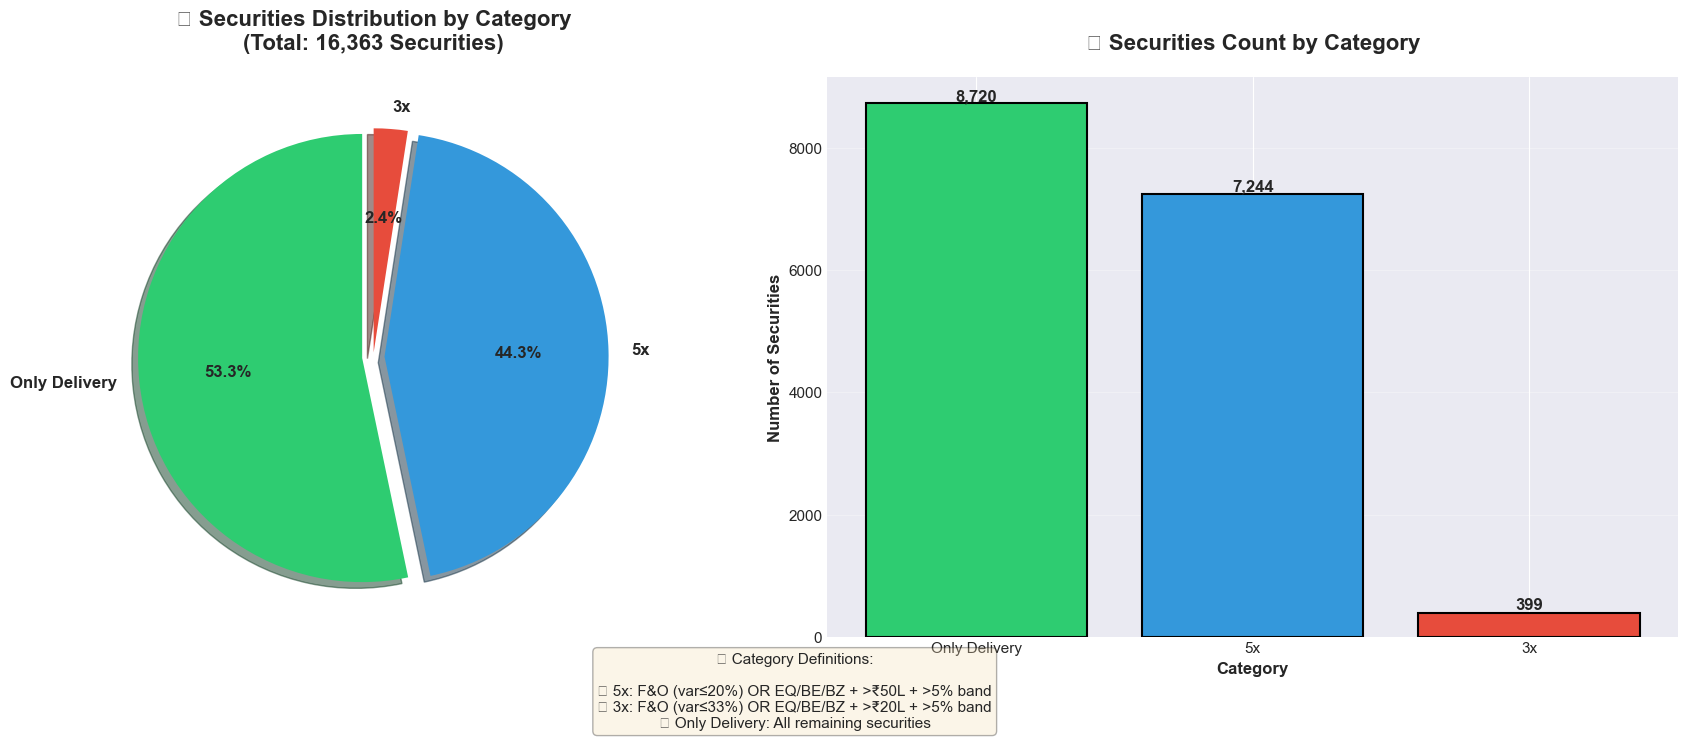

✅ Visualization 1 completed!

💡 KEY INSIGHT: Only Delivery category dominates with 8,720 securities (53.3%)


In [88]:


print(" Creating Visualization 1: Category Distribution Overview\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Left: Pie chart with percentages
category_counts = df_master['category'].value_counts()
colors = ['#2ecc71', '#3498db', '#e74c3c']  # Green, Blue, Red
explode = (0.05, 0.05, 0.02)  # Slightly separate slices

wedges, texts, autotexts = ax1.pie(
    category_counts.values, 
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=explode,
    shadow=True,
    textprops={'fontsize': 12, 'weight': 'bold'}
)

ax1.set_title('📊 Securities Distribution by Category\n(Total: {:,} Securities)'.format(len(df_master)), 
              fontsize=16, weight='bold', pad=20)

# Right: Bar chart with counts
bars = ax2.bar(category_counts.index, category_counts.values, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=12, weight='bold')

ax2.set_title('📈 Securities Count by Category', fontsize=16, weight='bold', pad=20)
ax2.set_ylabel('Number of Securities', fontsize=12, weight='bold')
ax2.set_xlabel('Category', fontsize=12, weight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add category definitions as text
textstr = '📋 Category Definitions:\n\n' \
          '🟢 5x: F&O (var≤20%) OR EQ/BE/BZ + >₹50L + >5% band\n' \
          '🔵 3x: F&O (var≤33%) OR EQ/BE/BZ + >₹20L + >5% band\n' \
          '🔴 Only Delivery: All remaining securities'

fig.text(0.5, -0.05, textstr, ha='center', fontsize=11, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

print("✅ Visualization 1 completed!")
print(f"\n💡 KEY INSIGHT: {category_counts.index[0]} category dominates with {category_counts.values[0]:,} securities ({category_counts.values[0]/len(df_master)*100:.1f}%)")

📊 Creating Visualization 2: Top Performers by Category



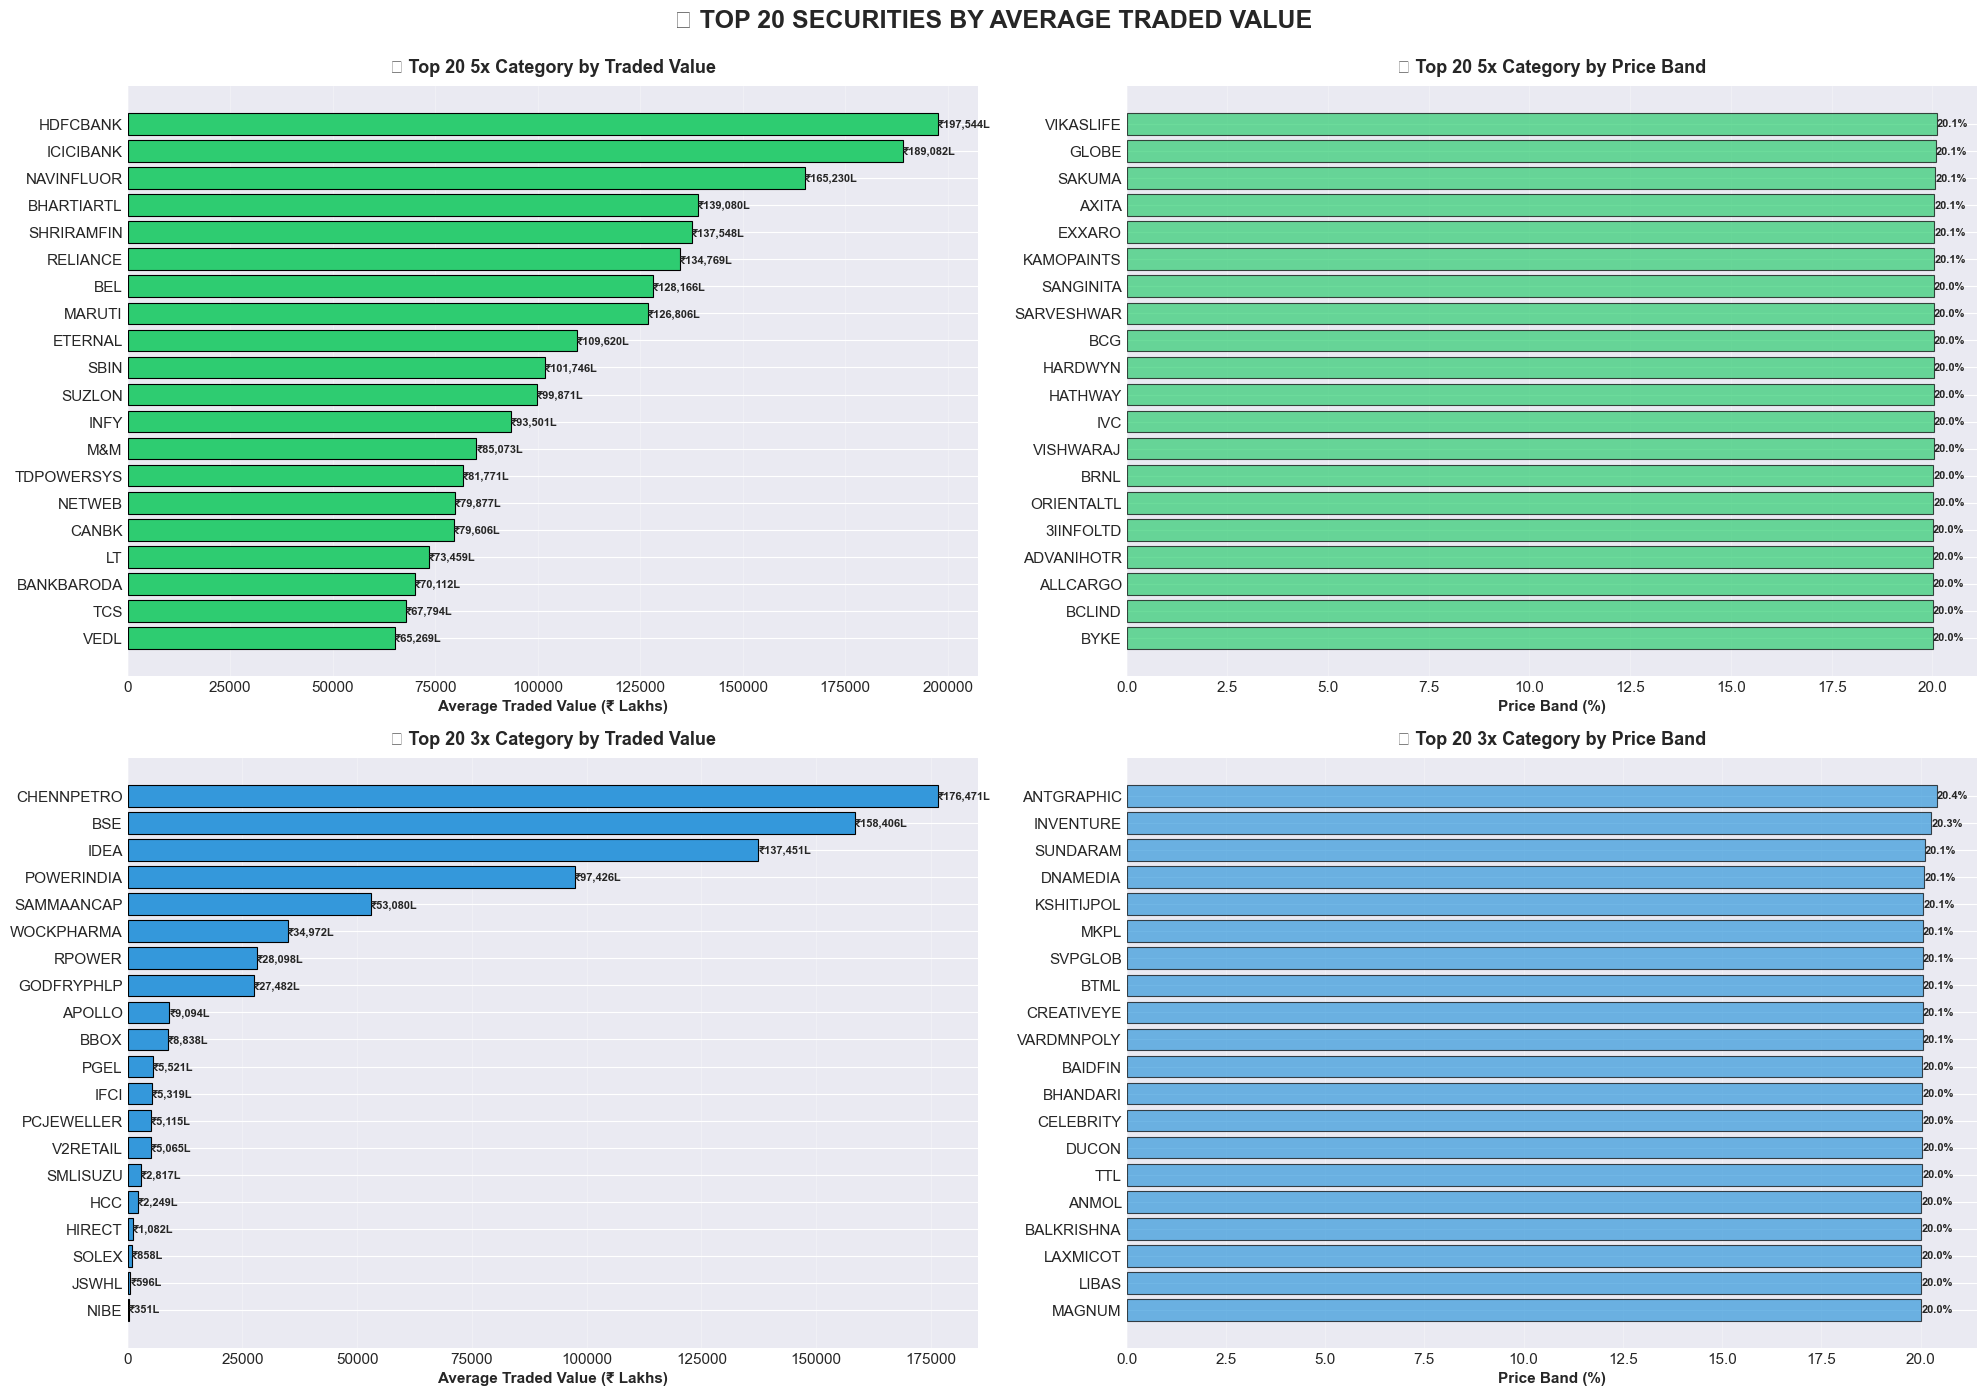

✅ Visualization 2 completed!

💡 KEY INSIGHTS:
   • 5x category has 7,244 high-liquidity stocks
   • 3x category has 399 medium-liquidity stocks
   • Top stocks show significantly higher trading volumes


In [89]:


print("📊 Creating Visualization 2: Top Performers by Category\n")

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('🏆 TOP 20 SECURITIES BY AVERAGE TRADED VALUE', fontsize=18, weight='bold', y=0.995)

categories = ['5x', '3x']
colors_map = {'5x': '#2ecc71', '3x': '#3498db'}

for idx, category in enumerate(categories):
    # Top 20 by traded value
    ax_val = axes[idx, 0]
    df_top_value = df_master[df_master['category'] == category].nlargest(20, 'avg_traded_value_lakhs')
    
    bars = ax_val.barh(df_top_value['symbol'], df_top_value['avg_traded_value_lakhs'], 
                       color=colors_map[category], edgecolor='black', linewidth=0.8)
    
    ax_val.set_xlabel('Average Traded Value (₹ Lakhs)', fontsize=11, weight='bold')
    ax_val.set_title(f'📈 Top 20 {category} Category by Traded Value', fontsize=13, weight='bold', pad=10)
    ax_val.invert_yaxis()
    ax_val.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for bar in bars:
        width = bar.get_width()
        ax_val.text(width, bar.get_y() + bar.get_height()/2,
                   f'₹{width:,.0f}L',
                   ha='left', va='center', fontsize=8, weight='bold')
    
    # Top 20 by price band (volatility)
    ax_band = axes[idx, 1]
    df_top_band = df_master[df_master['category'] == category].nlargest(20, 'price_band_pct')
    
    bars2 = ax_band.barh(df_top_band['symbol'], df_top_band['price_band_pct'], 
                         color=colors_map[category], alpha=0.7, edgecolor='black', linewidth=0.8)
    
    ax_band.set_xlabel('Price Band (%)', fontsize=11, weight='bold')
    ax_band.set_title(f'🎯 Top 20 {category} Category by Price Band', fontsize=13, weight='bold', pad=10)
    ax_band.invert_yaxis()
    ax_band.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for bar in bars2:
        width = bar.get_width()
        ax_band.text(width, bar.get_y() + bar.get_height()/2,
                    f'{width:.1f}%',
                    ha='left', va='center', fontsize=8, weight='bold')

plt.tight_layout()
plt.show()

print("✅ Visualization 2 completed!")
print("\n💡 KEY INSIGHTS:")
print(f"   • 5x category has {len(df_master[df_master['category']=='5x']):,} high-liquidity stocks")
print(f"   • 3x category has {len(df_master[df_master['category']=='3x']):,} medium-liquidity stocks")
print(f"   • Top stocks show significantly higher trading volumes")

📊 Creating Visualization 4: Trading Value Distribution Heatmap



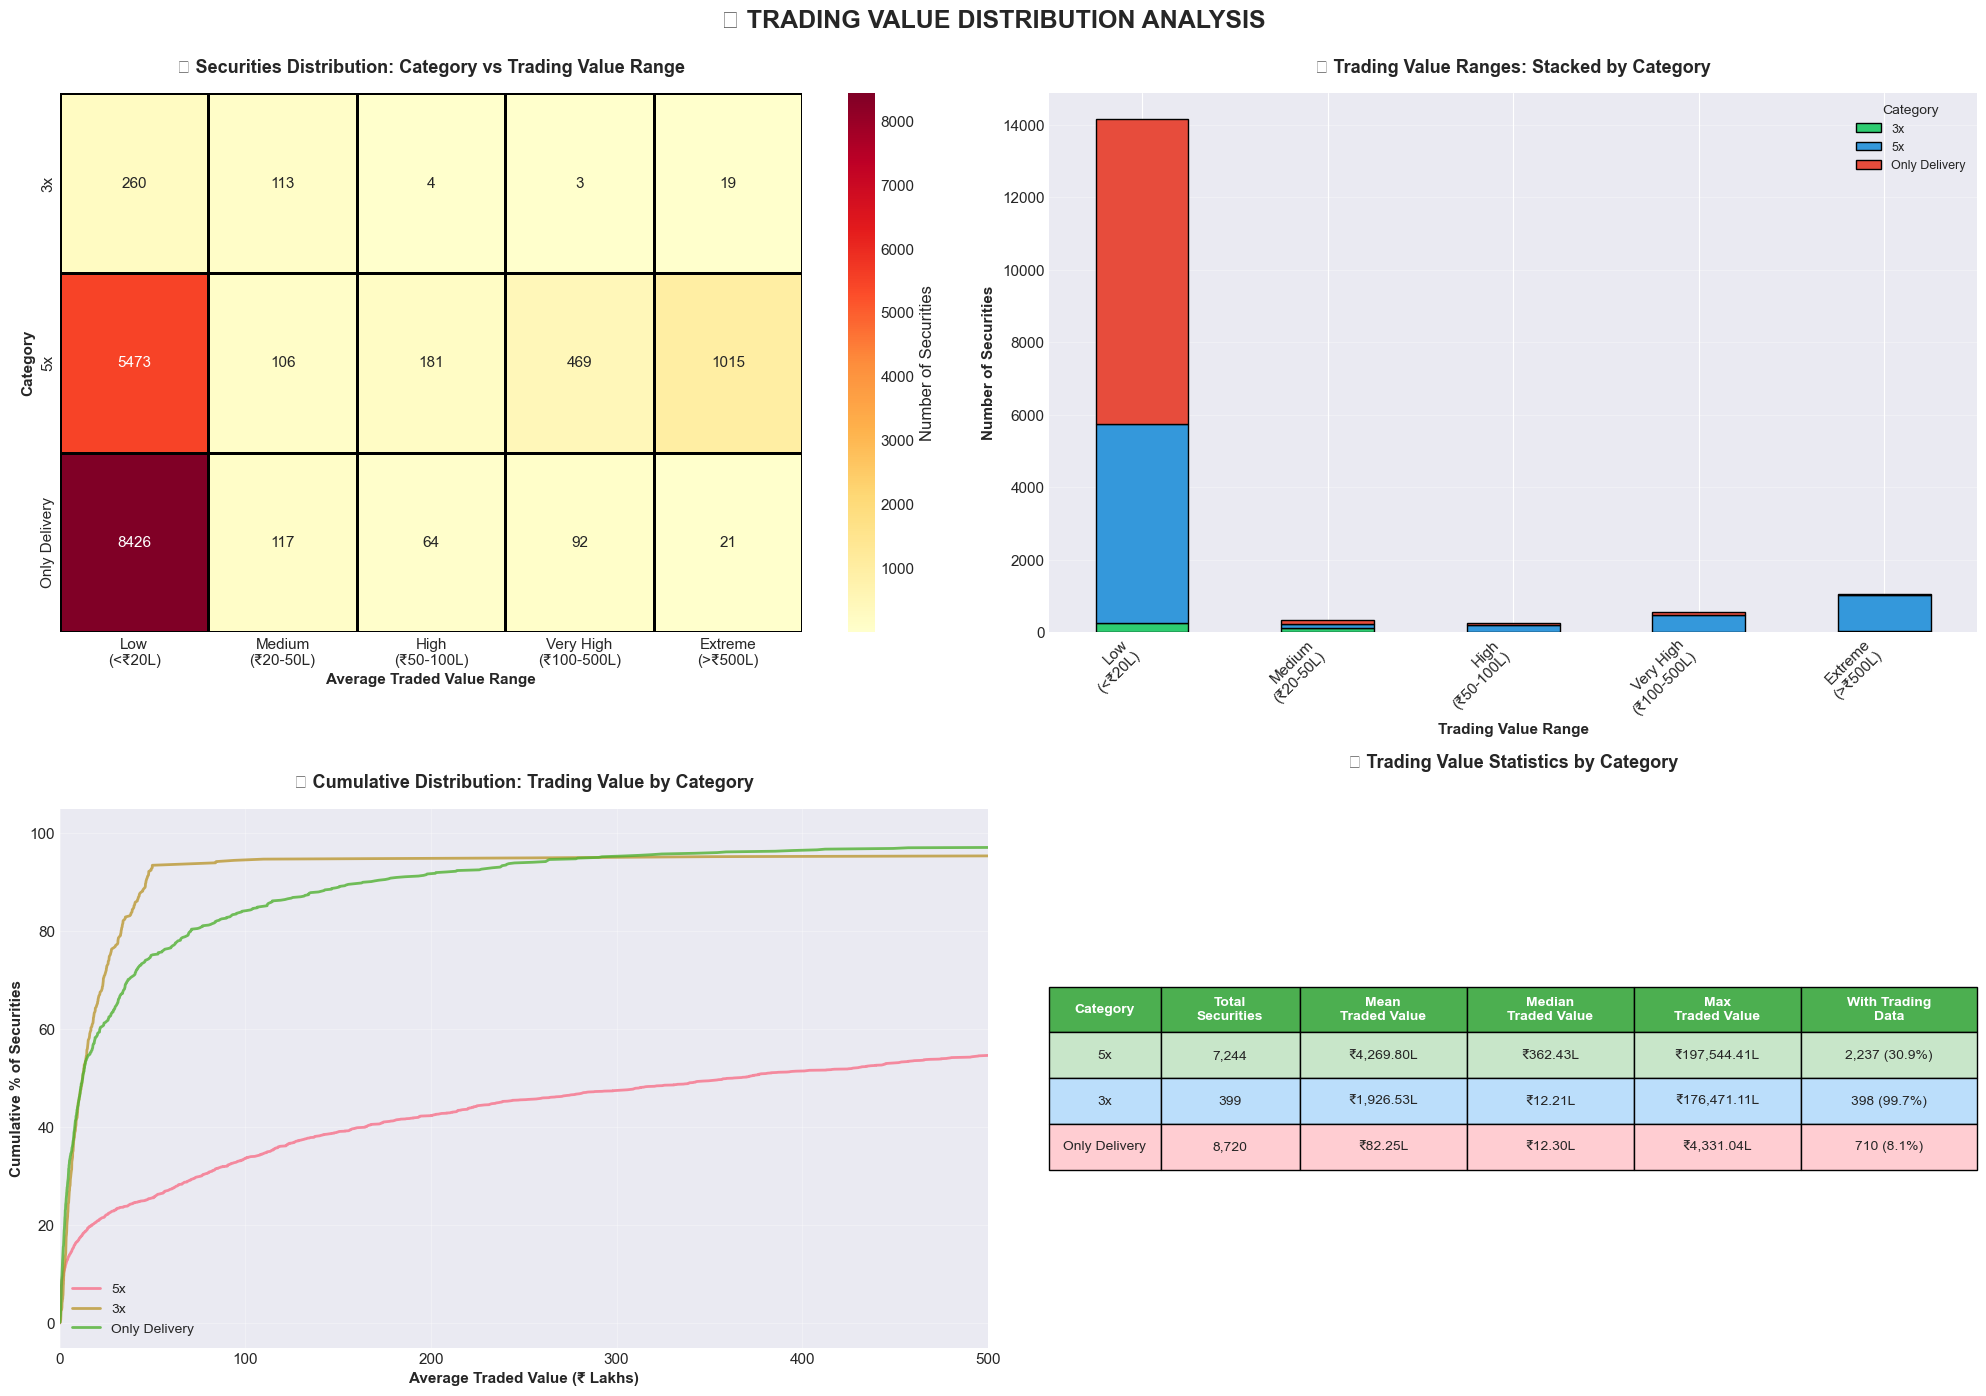

✅ Visualization 4 completed!

💡 KEY INSIGHTS:
   • 5x category: High trading volume concentration
   • 3x category: Medium trading volume spread
   • Only Delivery: Majority have low/no trading volume


In [90]:


print("📊 Creating Visualization 4: Trading Value Distribution Heatmap\n")

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('💰 TRADING VALUE DISTRIBUTION ANALYSIS', fontsize=18, weight='bold', y=0.995)

# Define value ranges
value_ranges = [
    (0, 20, 'Low\n(<₹20L)'),
    (20, 50, 'Medium\n(₹20-50L)'),
    (50, 100, 'High\n(₹50-100L)'),
    (100, 500, 'Very High\n(₹100-500L)'),
    (500, float('inf'), 'Extreme\n(>₹500L)')
]

# Create value range column
def categorize_value(val):
    for low, high, label in value_ranges:
        if low <= val < high:
            return label
    return value_ranges[-1][2]

df_master['value_range'] = df_master['avg_traded_value_lakhs'].apply(categorize_value)

# 1. Heatmap: Category vs Value Range
ax1 = axes[0, 0]
heatmap_data = pd.crosstab(df_master['category'], df_master['value_range'])

# Reorder columns
column_order = [label for _, _, label in value_ranges]
heatmap_data = heatmap_data.reindex(columns=column_order, fill_value=0)

sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', ax=ax1, 
            cbar_kws={'label': 'Number of Securities'}, linewidths=1, linecolor='black')

ax1.set_title('🔥 Securities Distribution: Category vs Trading Value Range', 
              fontsize=13, weight='bold', pad=15)
ax1.set_xlabel('Average Traded Value Range', fontsize=11, weight='bold')
ax1.set_ylabel('Category', fontsize=11, weight='bold')

# 2. Stacked bar: Value ranges by category
ax2 = axes[0, 1]
heatmap_data.T.plot(kind='bar', stacked=True, ax=ax2, 
                    color=['#2ecc71', '#3498db', '#e74c3c'], 
                    edgecolor='black', linewidth=1)

ax2.set_title('📊 Trading Value Ranges: Stacked by Category', fontsize=13, weight='bold', pad=15)
ax2.set_xlabel('Trading Value Range', fontsize=11, weight='bold')
ax2.set_ylabel('Number of Securities', fontsize=11, weight='bold')
ax2.legend(title='Category', title_fontsize=10, fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

# 3. Cumulative distribution
ax3 = axes[1, 0]

for category in ['5x', '3x', 'Only Delivery']:
    df_cat = df_master[df_master['category'] == category].sort_values('avg_traded_value_lakhs')
    df_cat_filtered = df_cat[df_cat['avg_traded_value_lakhs'] > 0]
    
    cumulative = np.cumsum(np.ones(len(df_cat_filtered))) / len(df_cat_filtered) * 100
    
    ax3.plot(df_cat_filtered['avg_traded_value_lakhs'], cumulative, 
             label=category, linewidth=2, alpha=0.8)

ax3.set_title('📈 Cumulative Distribution: Trading Value by Category', 
              fontsize=13, weight='bold', pad=15)
ax3.set_xlabel('Average Traded Value (₹ Lakhs)', fontsize=11, weight='bold')
ax3.set_ylabel('Cumulative % of Securities', fontsize=11, weight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 500)  # Focus on 0-500L range

# 4. Statistics table
ax4 = axes[1, 1]
ax4.axis('off')

# Calculate statistics
stats_data = []
for category in ['5x', '3x', 'Only Delivery']:
    df_cat = df_master[df_master['category'] == category]
    df_cat_with_data = df_cat[df_cat['avg_traded_value_lakhs'] > 0]
    
    stats_data.append([
        category,
        f"{len(df_cat):,}",
        f"₹{df_cat_with_data['avg_traded_value_lakhs'].mean():,.2f}L",
        f"₹{df_cat_with_data['avg_traded_value_lakhs'].median():,.2f}L",
        f"₹{df_cat_with_data['avg_traded_value_lakhs'].max():,.2f}L",
        f"{len(df_cat_with_data):,} ({len(df_cat_with_data)/len(df_cat)*100:.1f}%)"
    ])

stats_df = pd.DataFrame(stats_data, columns=[
    'Category', 'Total\nSecurities', 'Mean\nTraded Value', 
    'Median\nTraded Value', 'Max\nTraded Value', 'With Trading\nData'
])

table = ax4.table(cellText=stats_df.values, colLabels=stats_df.columns,
                  cellLoc='center', loc='center',
                  colWidths=[0.12, 0.15, 0.18, 0.18, 0.18, 0.19])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Color header
for i in range(len(stats_df.columns)):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Color rows
colors = ['#c8e6c9', '#bbdefb', '#ffcdd2']
for i in range(len(stats_data)):
    for j in range(len(stats_df.columns)):
        table[(i+1, j)].set_facecolor(colors[i])

ax4.set_title('📊 Trading Value Statistics by Category', fontsize=13, weight='bold', pad=30)

plt.tight_layout()
plt.show()

print("✅ Visualization 4 completed!")
print("\n💡 KEY INSIGHTS:")
print(f"   • 5x category: High trading volume concentration")
print(f"   • 3x category: Medium trading volume spread")
print(f"   • Only Delivery: Majority have low/no trading volume")

📊 Creating Visualization 5: Sweet Spot Analysis (Price Band vs Traded Value)



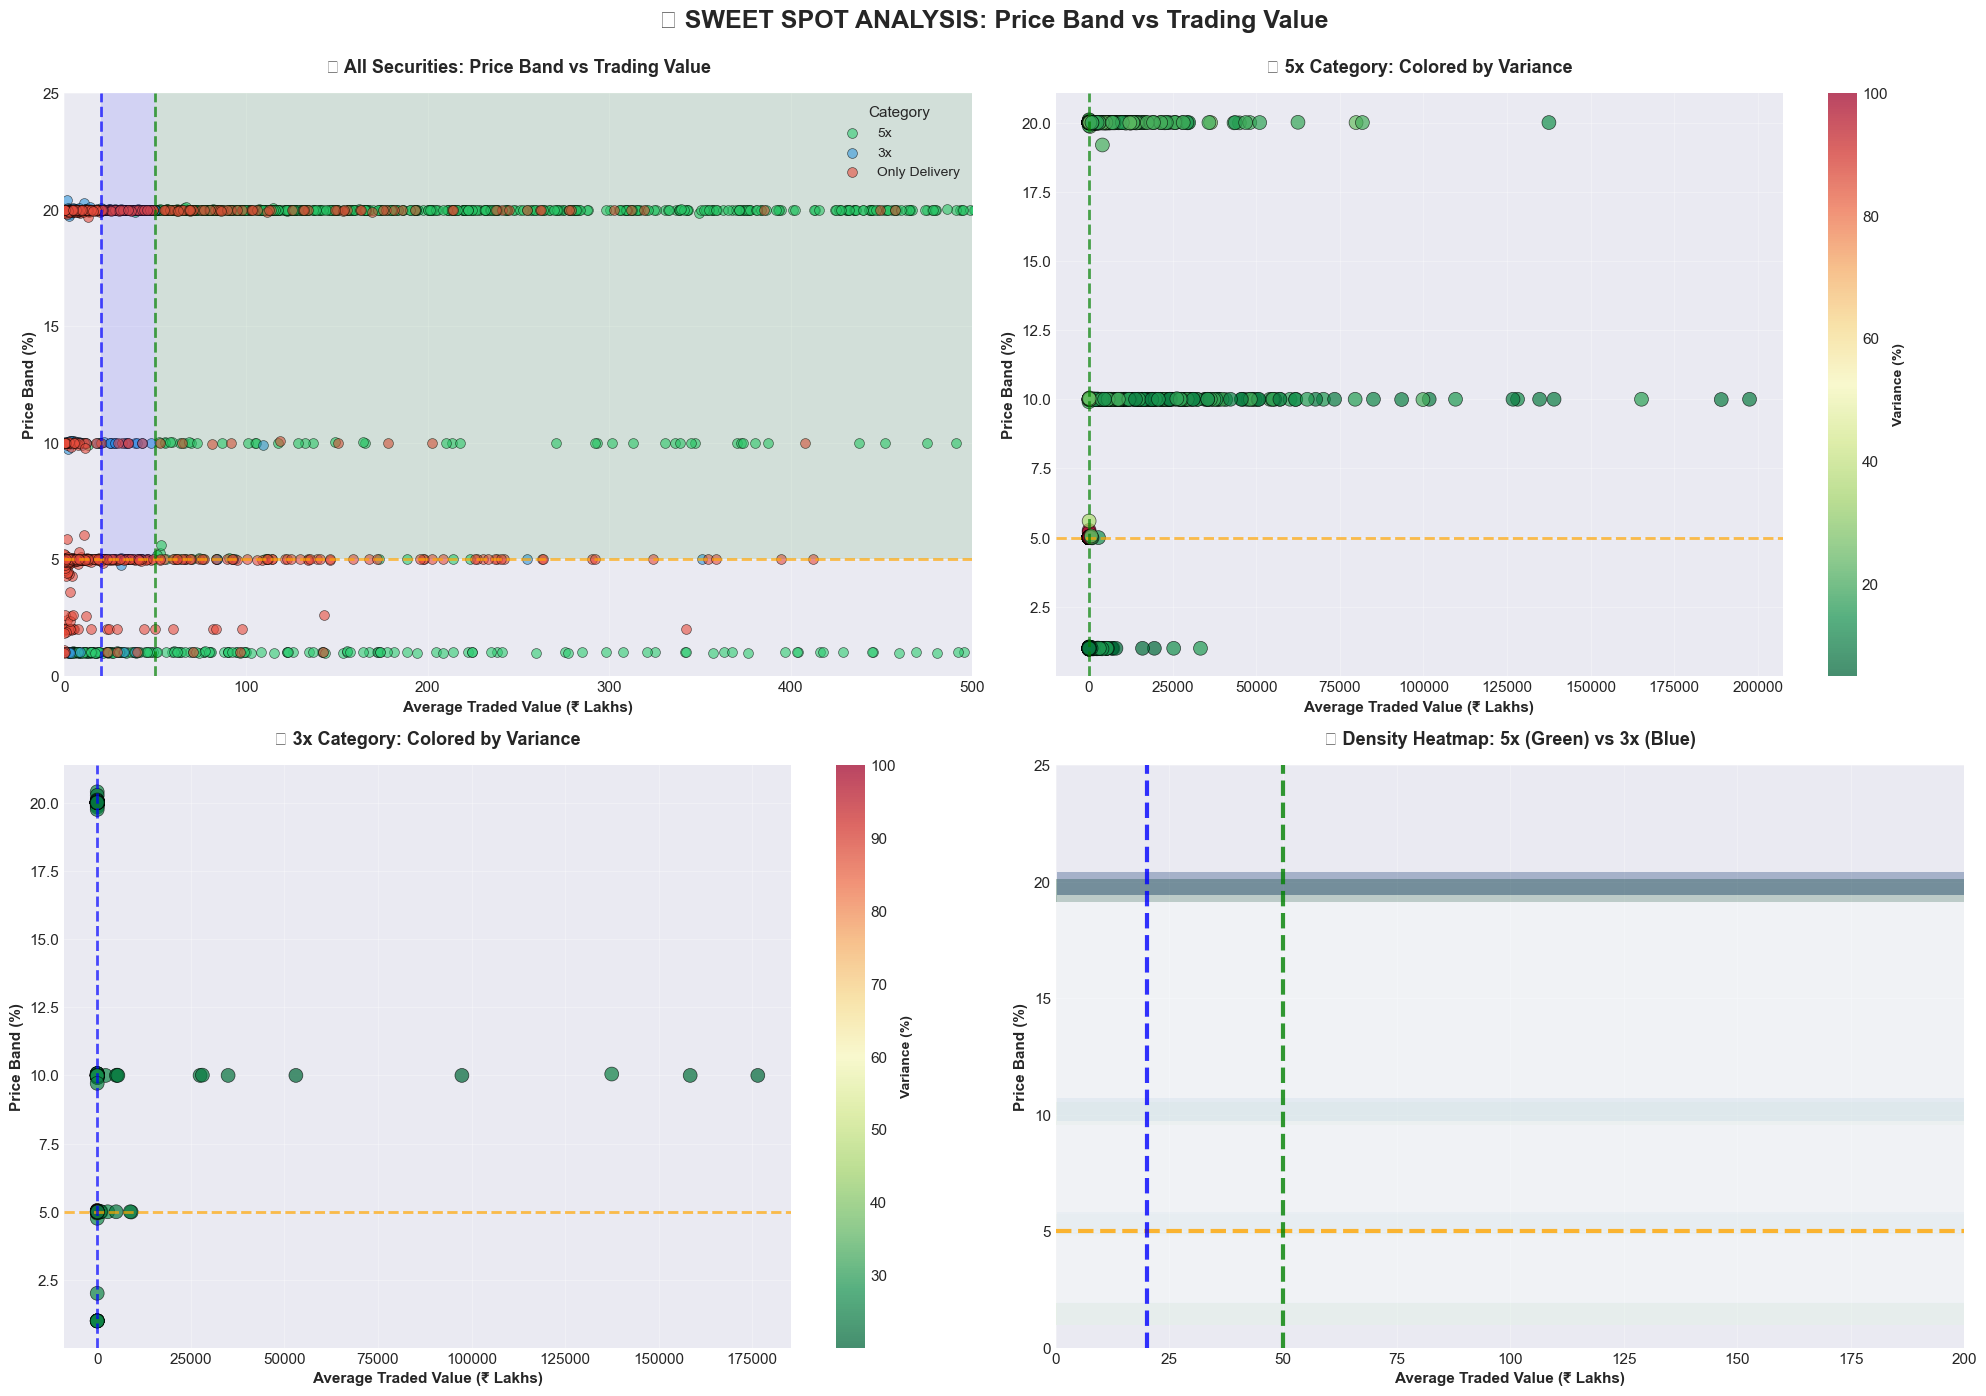

✅ Visualization 5 completed!

💡 KEY INSIGHTS:
   • 5x Sweet Spot: >₹50L traded value + >5% price band
   • 3x Sweet Spot: ₹20-50L traded value + >5% price band
   • Lower variance (green) = Better for higher leverage
   • Density shows concentration of securities in each category


In [91]:


print("📊 Creating Visualization 5: Sweet Spot Analysis (Price Band vs Traded Value)\n")

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('🔥 SWEET SPOT ANALYSIS: Price Band vs Trading Value', fontsize=18, weight='bold', y=0.995)

# Filter data with trading activity
df_with_trading = df_master[df_master['avg_traded_value_lakhs'] > 0].copy()

# 1. Main scatter plot - All categories
ax1 = axes[0, 0]

for category, color in [('5x', '#2ecc71'), ('3x', '#3498db'), ('Only Delivery', '#e74c3c')]:
    df_cat = df_with_trading[df_with_trading['category'] == category]
    ax1.scatter(df_cat['avg_traded_value_lakhs'], df_cat['price_band_pct'], 
               label=category, alpha=0.6, s=50, color=color, edgecolors='black', linewidth=0.5)

ax1.set_xlabel('Average Traded Value (₹ Lakhs)', fontsize=11, weight='bold')
ax1.set_ylabel('Price Band (%)', fontsize=11, weight='bold')
ax1.set_title('🎯 All Securities: Price Band vs Trading Value', fontsize=13, weight='bold', pad=15)
ax1.legend(fontsize=10, title='Category', title_fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 500)
ax1.set_ylim(0, 25)

# Add threshold lines
ax1.axhline(y=5, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='5% Price Band')
ax1.axvline(x=20, color='blue', linestyle='--', linewidth=2, alpha=0.7, label='₹20L Threshold')
ax1.axvline(x=50, color='green', linestyle='--', linewidth=2, alpha=0.7, label='₹50L Threshold')

# Highlight "sweet spots"
ax1.add_patch(Rectangle((50, 5), 450, 20, alpha=0.1, facecolor='green', 
                        label='5x Sweet Spot'))
ax1.add_patch(Rectangle((20, 5), 30, 20, alpha=0.1, facecolor='blue', 
                        label='3x Sweet Spot'))

# 2. Zoomed view: 5x category
ax2 = axes[0, 1]
df_5x = df_with_trading[df_with_trading['category'] == '5x']

scatter = ax2.scatter(df_5x['avg_traded_value_lakhs'], df_5x['price_band_pct'],
                     c=df_5x['variance'], cmap='RdYlGn_r', s=100, 
                     alpha=0.7, edgecolors='black', linewidth=0.5)

ax2.set_xlabel('Average Traded Value (₹ Lakhs)', fontsize=11, weight='bold')
ax2.set_ylabel('Price Band (%)', fontsize=11, weight='bold')
ax2.set_title('🟢 5x Category: Colored by Variance', fontsize=13, weight='bold', pad=15)
ax2.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Variance (%)', fontsize=10, weight='bold')

# Add threshold lines
ax2.axhline(y=5, color='orange', linestyle='--', linewidth=2, alpha=0.7)
ax2.axvline(x=50, color='green', linestyle='--', linewidth=2, alpha=0.7)

# 3. Zoomed view: 3x category
ax3 = axes[1, 0]
df_3x = df_with_trading[df_with_trading['category'] == '3x']

scatter2 = ax3.scatter(df_3x['avg_traded_value_lakhs'], df_3x['price_band_pct'],
                      c=df_3x['variance'], cmap='RdYlGn_r', s=100,
                      alpha=0.7, edgecolors='black', linewidth=0.5)

ax3.set_xlabel('Average Traded Value (₹ Lakhs)', fontsize=11, weight='bold')
ax3.set_ylabel('Price Band (%)', fontsize=11, weight='bold')
ax3.set_title('🔵 3x Category: Colored by Variance', fontsize=13, weight='bold', pad=15)
ax3.grid(True, alpha=0.3)

cbar2 = plt.colorbar(scatter2, ax=ax3)
cbar2.set_label('Variance (%)', fontsize=10, weight='bold')

# Add threshold lines
ax3.axhline(y=5, color='orange', linestyle='--', linewidth=2, alpha=0.7)
ax3.axvline(x=20, color='blue', linestyle='--', linewidth=2, alpha=0.7)

# 4. Density plot
ax4 = axes[1, 1]

# Create 2D histogram for density
for category, color in [('5x', '#2ecc71'), ('3x', '#3498db')]:
    df_cat = df_with_trading[df_with_trading['category'] == category]
    
    ax4.hist2d(df_cat['avg_traded_value_lakhs'], df_cat['price_band_pct'],
              bins=20, alpha=0.3, cmap='Greens' if category=='5x' else 'Blues')

ax4.set_xlabel('Average Traded Value (₹ Lakhs)', fontsize=11, weight='bold')
ax4.set_ylabel('Price Band (%)', fontsize=11, weight='bold')
ax4.set_title('🔥 Density Heatmap: 5x (Green) vs 3x (Blue)', fontsize=13, weight='bold', pad=15)
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, 200)
ax4.set_ylim(0, 25)

# Add threshold lines
ax4.axhline(y=5, color='orange', linestyle='--', linewidth=3, alpha=0.8)
ax4.axvline(x=20, color='blue', linestyle='--', linewidth=3, alpha=0.8)
ax4.axvline(x=50, color='green', linestyle='--', linewidth=3, alpha=0.8)

plt.tight_layout()
plt.show()

print("✅ Visualization 5 completed!")
print("\n💡 KEY INSIGHTS:")
print(f"   • 5x Sweet Spot: >₹50L traded value + >5% price band")
print(f"   • 3x Sweet Spot: ₹20-50L traded value + >5% price band")
print(f"   • Lower variance (green) = Better for higher leverage")
print(f"   • Density shows concentration of securities in each category")